### 建置課程

In [ ]:
# 上傳到 lightRAG
import requests
url = "http://localhost:9621/documents/upload"
course_id = "Freshman_Chinese"

# file_name = "PCR：汗水、淚水、超前部署.pdf"
# file_name = "我國海洋空間規劃建制面臨之智識挑戰.pdf"
file_name = "2020年人口及住宅普查.pdf"
file_path = f"data/{course_id}/{file_name}"

params = {
    "course_id": course_id
}
files = {
    "file": open(file_path, "rb")
}
response = requests.post(url, params=params, files=files)
print("Upload file to LightRAG result: ",response.json())

Upload file to LightRAG result:  {'status': 'success', 'message': "File '2020年人口及住宅普查.pdf' uploaded successfully. Processing will continue in background."}


### 建立 mindmap

In [ ]:
import pymupdf4llm
from main import openai_complete, LightRAG_retrieve_nodes, KC_extract
import json
# file_name = "PCR：汗水、淚水、超前部署.pdf"
# file_name = "我國海洋空間規劃建制面臨之智識挑戰.pdf"
file_name = "2020年人口及住宅普查.pdf"
course_id = "Freshman_Chinese"
pdf_markdown = pymupdf4llm.to_markdown(f"data/{course_id}/{file_name}")

# 建立心智圖
system_prompt = f"""請將以下文章內容整理為一份完整的心智圖（Mind Map），以 JSON 格式表示。心智圖應為主題 → 子主題 → 細節的階層結構，並滿足以下要求：
1. 每個節點請使用如下格式：
   {{
     "id": "唯一識別碼（可使用英文小寫與數字）",
     "topic": "節點名稱（請用簡短字詞表示）",
     "children": [ ... ]
   }}
2. 根節點為整體主題，下層包含應用、範例、相關概念等內容，請盡可能展開多層結構。
3. 回傳格式僅為 JSON，不要加入說明文字或額外標註。
"""
user_prompt = f"""文章內容：{pdf_markdown}"""
mindmap_str = openai_complete(user_prompt, system_prompt=system_prompt, json_mode=True)
mindmap = json.loads(mindmap_str)
print("generate mindmap success!")

# 建立 mindmap 的知識點
def traverse_mindmap(node):
    # 使用節點的 topic 作為查詢文字
    query_text = node['topic']
    tmp_results = LightRAG_retrieve_nodes(query=query_text, mode="hybrid", top_k=5, course_id=course_id)
    if tmp_results and not tmp_results["Entities"].empty:
        results = KC_extract(tmp_results["Entities"])
        # 將 results 加入到節點中，確保 results 不為 None
        node["knowledge_points"] = results[:5] if results is not None else []
    else:
        node["knowledge_points"] = []
    
    # 遞迴處理所有子節點
    if 'children' in node and node['children']:
        for child in node['children']:
            traverse_mindmap(child)

traverse_mindmap(mindmap)

# 保存生成的心智圖
mindmap_entry = {
    'file_name': file_name,
    'mindmap': mindmap
}
mindmap_path = f"data/{course_id}/mindmap.jsonl"
with open(mindmap_path, 'a', encoding='utf-8') as f:
    f.write(json.dumps(mindmap_entry, ensure_ascii=False) + '\n')

generate mindmap success!


In [40]:
# 印出心智圖
file_name = "我國海洋空間規劃建制面臨之智識挑戰.pdf"
mindmap_path = f"data/{course_id}/mindmap.jsonl"

# 讀取 mindmap 檔案
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == file_name:
            mindmap = data['mindmap']
            break

# 遞迴印出 mindmap 的 topic
def print_mindmap(node, level=0):
    print("  " * level + "- " + node['topic']+": "+", ".join([kc['KC_name'] for kc in node['knowledge_points']]))
    if 'children' in node and node['children']:
        for child in node['children']:
            print_mindmap(child, level + 1)

print("\n心智圖結構:")
print_mindmap(mindmap)


心智圖結構:
- 自由共和國: 政府決策, 經濟變化, 國土一體、海陸分治, 海域管理法, 行政院
  - 海洋空間規劃: 海洋空間規劃, 適應性管理, 生態系, 人類使用, 海洋環境管理工具
    - 定義: 以生態系為基礎之管理, 海洋空間規劃, 生態系, 人類使用, Research Student
      - 海洋空間規劃概念: 以生態系為基礎之管理, 海洋空間規劃, 適應性管理, 生態系, 人類使用
      - 適應性管理: 海洋治理, 海洋空間規劃, 以生態系為基礎之管理, 適應性管理, 生態系
    - 重要性: COVID-19, PCR (聚合酶鏈式反應), PCR (Polymerase Chain Reaction), Research Student, Scientific Publication
      - 海洋永續發展: 海洋空間規劃, 適應性管理, 生態系, 人類使用, 海域風力發電
      - 衝突調和: 人類使用, 海洋空間規劃, 家庭結構, 離婚人口, 財富集中
    - 挑戰: 海洋治理, 海洋空間規劃, Research Student, Sweat and Dedication, 尺度錯置
      - 誤解本質: Research Student, Sweat and Dedication, 尺度錯置, 海洋治理, 財富集中
      - 尺度錯置: 海洋空間規劃, 適應性管理, 尺度錯置, 海洋治理, 棘手問題
    - 關鍵要素: 以生態系為基礎之管理, 海洋空間規劃, 最佳可得科學資訊, 財富集中, 貧富不均
      - 事前評估: 最佳可得科學資訊, 海洋空間規劃, 適應性管理, 政府決策, 經濟變化
      - 現況分析: 2020年人口及住宅普查, 未婚人口, 人口成長趨緩, 政府決策, 經濟變化
      - 未來情境模擬: 最佳可得科學資訊, 海洋空間規劃, 適應性管理, 人類使用, 生態系
      - 監測與評鑑: 最佳可得科學資訊, 海洋空間規劃, 適應性管理, 2020年人口及住宅普查, 人口成長趨緩
    - 以生態系為基礎之管理: 以生態系為基礎之管理, 海洋空間規劃, 生態系, 人類使用, 海洋永續發展
      - 人類干預: 人類使用, 海洋空

### 進行追蹤 (基於隱密資訊考量資料未公開)

In [17]:
import pandas as pd
# 讀取對話紀錄檔案
df = pd.read_csv('data/Freshman_Chinese/學生對話紀錄_新.csv')
print("成功讀取對話紀錄檔案")
print(f"共有 {len(df)} 筆對話記錄")

成功讀取對話紀錄檔案
共有 102 筆對話記錄


In [ ]:
import main
from tqdm import tqdm
import json
course_id = "Freshman_Chinese"

# 遍歷 df 中的每一筆對話紀錄
for index, row in tqdm(df.iterrows(), total=len(df), desc="處理對話紀錄"):
    dialogue = json.loads(row['對話紀錄'])
    anno_nodes, KC_information = main.annotate_knowledge_points(dialogue, course_id)
    
    if len(anno_nodes) > 5:
        # 每5個節點分組處理
        for i in range(0, len(anno_nodes), 5):
            nodes_subset = anno_nodes[i:i+5]
            anno_mastery = main.annotate_mastery(
                row['學號'],
                nodes_subset,
                KC_information,
                dialogue,
                time=row['時間'],
                course_id=course_id,
                user_name=row['姓名'],
                conversation_id=row['conv_ID'],
                update_user_status=True,
                store_trace_result=True
            )
    else:
        # 如果節點數小於等於5，直接處理全部
        anno_mastery = main.annotate_mastery(
            row['學號'],
            anno_nodes,
            KC_information,
            dialogue,
            time=row['時間'],
            course_id=course_id,
            user_name=row['姓名'],
            conversation_id=row['conv_ID'],
            update_user_status=True,
            store_trace_result=True
        )

In [20]:
def calculate_topic_scores(mindmap, user_status):
    # 建立主題與知識點的對應
    topic_kcs = {}
    
    # 遞迴函式來收集子節點的知識點
    def collect_kcs(node):
        kcs = set()
        if 'knowledge_points' in node and node['knowledge_points']:
            kcs.update(kp['KC_name'] for kp in node['knowledge_points'])
        if 'children' in node:
            for child in node['children']:
                kcs.update(collect_kcs(child))
        return kcs

    # 處理第一層主題
    for child in mindmap['children']:
        topic_name = child['topic']
        topic_kcs[topic_name] = collect_kcs(child)

    # 計算每個主題的分數
    topic_scores = {}
    for topic, kcs in topic_kcs.items():
        total_score = 0
        valid_kc_count = 0
        
        # 檢查每個知識點是否有掌握度紀錄
        for kc in kcs:
            for kc_status in user_status['user_KC_status']:
                if kc_status['KC_name'] == kc:
                    total_score += kc_status['mastery_score']
                    valid_kc_count += 1
                    break
        
        # 計算主題平均分數
        if valid_kc_count > 0:
            topic_scores[topic] = total_score / len(kcs)
        else:
            topic_scores[topic] = 0
            
    # 計算總分
    overall_score = sum(topic_scores.values()) / len(topic_scores) if topic_scores else 0
    
    return topic_scores, overall_score

In [ ]:
# 嘗試計算單個學生的單個作業掌握分數
student_id = 113403005
file_name = "PCR：汗水、淚水、超前部署.pdf"
course_id = "Freshman_Chinese"
mindmap_path = f"data/{course_id}/mindmap.jsonl"
status_path = f"data/{course_id}/user_status.jsonl"

mindmap = {}
# 計算每個主題的分數
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == file_name:
            mindmap = data['mindmap']
            break
# 取得使用者狀態
user_status = {}
with open(status_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['user_id'] == student_id:
            user_status = data
            break

print([ kc["KC_name"] for kc in user_status["user_KC_status"]])
topic_scores, overall_score = calculate_topic_scores(mindmap, user_status)

# 輸出每個主題的分數
print("\n各主題掌握度：")
for topic, score in topic_scores.items():
    print(f"{topic}: {score:.2f}")

# 計算整體作業掌握分數
overall_score = sum(topic_scores.values()) / len(topic_scores) if topic_scores else 0
print(f"\n整體作業掌握度：{overall_score:.2f}")

['PCR技術', '資料庫管理與SQL語言', '海洋治理', '海洋空間規劃', '以生態系為基礎之管理', '適應性管理', 'UNESCO出版品', '平議2020年人口及住宅普查']

各主題掌握度：
PCR概述: 0.07
實驗室經驗: 0.06
PCR的未來: 0.05

整體作業掌握度：0.06


### 資料前處理: 教材心智圖 + 學生成績

In [33]:
file_name_list = ["PCR：汗水、淚水、超前部署.pdf", "我國海洋空間規劃建制面臨之智識挑戰.pdf", "2020年人口及住宅普查.pdf"]
mindmap_path = f"data/Freshman_Chinese/mindmap.jsonl"

# 讀取並建立 mindmap_dict
mindmap_dict = {}
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] in file_name_list:
            mindmap_dict[data['file_name']] = data['mindmap']

# 建立主題與知識點的對應
topic_kcs = {}

# 遞迴函式來收集子節點的知識點
def collect_kcs(node):
    kcs = set()
    if 'knowledge_points' in node and node['knowledge_points']:
        kcs.update(kp['KC_name'] for kp in node['knowledge_points'])
    if 'children' in node:
        for child in node['children']:
            kcs.update(collect_kcs(child))
    return kcs

# 處理每個 mindmap 的主題和知識點
for file_name, mindmap in mindmap_dict.items():
    print(f"\n{file_name} 的主題與知識點:")
    print("主題數量:",len(mindmap['children']))
    
    # 處理第一層主題
    for child in mindmap['children']:
        topic_name = child['topic']
        kcs = collect_kcs(child)
        print(f"主題: {topic_name}")
        print(f"知識點數量: {len(kcs)}")
        print("相關知識點:")
        for kc in kcs:
            print(f"- {kc}")



PCR：汗水、淚水、超前部署.pdf 的主題與知識點:
主題數量: 3
主題: PCR概述
知識點數量: 20
相關知識點:
- 經濟變化
- 最佳可得科學資訊
- Scientific Publication
- 以生態系為基礎之管理
- Sweat and Dedication
- 貧富不均
- UNESCO出版品
- 生態系
- Russian Female Professor
- Research Student
- 財富集中
- 人類使用
- COVID-19
- PCR (Polymerase Chain Reaction)
- Kary B. Mullis
- PCR (聚合酶鏈式反應)
- Automated PCR Instruments
- 海洋空間規劃
- 信任下降
- 政府決策
主題: 實驗室經驗
知識點數量: 22
相關知識點:
- 離婚人口
- 未婚人口
- 房價上漲
- 最佳可得科學資訊
- Scientific Publication
- 海洋治理
- Sweat and Dedication
- 貧富不均
- UNESCO出版品
- 少子化
- 2020年人口及住宅普查
- 生態系
- Russian Female Professor
- Research Student
- 財富集中
- 人類使用
- PCR (Polymerase Chain Reaction)
- PCR (聚合酶鏈式反應)
- 主任
- 海洋空間規劃
- 中心
- 家庭結構
主題: PCR的未來
知識點數量: 19
相關知識點:
- 離婚人口
- 家庭結構
- 最佳可得科學資訊
- 人口成長趨緩
- Sweat and Dedication
- 2020年人口及住宅普查
- 海域風力發電
- Russian Female Professor
- Research Student
- 人類使用
- COVID-19
- PCR (Polymerase Chain Reaction)
- 管理
- PCR (聚合酶鏈式反應)
- Automated PCR Instruments
- 主任
- 海洋空間規劃
- 政府決策
- 適應性管理

我國海洋空間規劃建制面臨之智識挑戰.pdf 的主題與知識點:
主題數量: 3
主題: 海洋空間規劃
知識點數量: 28
相

In [28]:
# 讀取課程作業成績資料
import pandas as pd
from tqdm import tqdm

# 讀取CSV檔案
df_grade = pd.read_csv('data/Freshman_Chinese/課程作業成績.csv', encoding='utf-8')
df_dialogue = pd.read_csv('data/Freshman_Chinese/對話紀錄有無.csv', encoding='utf-8')

course_id = "Freshman_Chinese"
file_name_list = ["PCR：汗水、淚水、超前部署.pdf", "我國海洋空間規劃建制面臨之智識挑戰.pdf", "2020年人口及住宅普查.pdf"]
mindmap_path = f"data/{course_id}/mindmap.jsonl"
status_path = f"data/{course_id}/user_status.jsonl"
mindmap_dict = {}
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] in file_name_list:
            mindmap_dict[data['file_name']] = data['mindmap']

print(mindmap_dict.keys())

def get_user_status(status_path, student_id):
    with open(status_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['user_id'] == student_id:
                return data
    return None

# 建立儲存結果的DataFrame
result_df = pd.DataFrame(columns=['項次', '帳號', '姓名', 'PCR：汗水、淚水、超前部署', 
                                 '我國海洋空間規劃建制面臨之智識挑戰', '平議2020年人口及住宅普查'])

for idx in tqdm(df_grade.index, desc="處理對話紀錄"):
    row_grade = df_grade.loc[idx]
    row_dialogue = df_dialogue.loc[idx]
    
    # 初始化該學生的資料
    student_data = {
        '項次': idx + 1,
        '帳號': row_grade['帳號'],
        '姓名': row_grade['姓名'],
        'PCR：汗水、淚水、超前部署': None,
        '我國海洋空間規劃建制面臨之智識挑戰': None,
        '平議2020年人口及住宅普查': None
    }
    
    if pd.notna(row_grade['PCR：汗水、淚水、超前部署']) and pd.notna(row_dialogue['PCR：汗水、淚水、超前部署']):
        topic_scores, overall_score = calculate_topic_scores(mindmap_dict['PCR：汗水、淚水、超前部署.pdf'], get_user_status(status_path, row_grade['帳號']))
        student_data['PCR：汗水、淚水、超前部署'] = overall_score
        
    if pd.notna(row_grade['我國海洋空間規劃建制面臨之智識挑戰']) and pd.notna(row_dialogue['我國海洋空間規劃建制面臨之智識挑戰']):
        topic_scores, overall_score = calculate_topic_scores(mindmap_dict['我國海洋空間規劃建制面臨之智識挑戰.pdf'], get_user_status(status_path, row_grade['帳號']))
        student_data['我國海洋空間規劃建制面臨之智識挑戰'] = overall_score
        
    if pd.notna(row_grade['平議2020年人口及住宅普查']) and pd.notna(row_dialogue['平議2020年人口及住宅普查']):
        topic_scores, overall_score = calculate_topic_scores(mindmap_dict['2020年人口及住宅普查.pdf'], get_user_status(status_path, row_grade['帳號']))
        student_data['平議2020年人口及住宅普查'] = overall_score
        
    # result_df = result_df.append(student_data, ignore_index=True)
    result_df = pd.concat([result_df, pd.DataFrame([student_data])], ignore_index=True)

# 儲存結果到CSV
result_df.to_csv('data/Freshman_Chinese/系統掌握分數.csv', index=False, encoding='utf-8')


dict_keys(['PCR：汗水、淚水、超前部署.pdf', '我國海洋空間規劃建制面臨之智識挑戰.pdf', '2020年人口及住宅普查.pdf'])


處理對話紀錄:   0%|          | 0/37 [00:00<?, ?it/s]C:\Users\water\AppData\Local\Temp\ipykernel_7160\12748011.py:61: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  result_df = pd.concat([result_df, pd.DataFrame([student_data])], ignore_index=True)
處理對話紀錄: 100%|██████████| 37/37 [00:00<00:00, 362.10it/s]


In [29]:
import pandas as pd

# 讀取CSV檔案
system_scores = pd.read_csv('data/Freshman_Chinese/系統掌握分數.csv')
course_scores = pd.read_csv('data/Freshman_Chinese/課程作業成績.csv')

# 建立新的 DataFrame 來儲存過濾後的資料
filtered_system = system_scores.copy()
filtered_course = course_scores.copy()

for idx in range(len(system_scores)):
    # PCR作業
    if not (pd.notna(system_scores.iloc[idx]['PCR：汗水、淚水、超前部署']) and pd.notna(course_scores.iloc[idx]['PCR：汗水、淚水、超前部署'])):
        filtered_system.at[idx, 'PCR：汗水、淚水、超前部署'] = None
        filtered_course.at[idx, 'PCR：汗水、淚水、超前部署'] = None
        
    # 海洋空間規劃作業    
    if not (pd.notna(system_scores.iloc[idx]['我國海洋空間規劃建制面臨之智識挑戰']) and pd.notna(course_scores.iloc[idx]['我國海洋空間規劃建制面臨之智識挑戰'])):
        filtered_system.at[idx, '我國海洋空間規劃建制面臨之智識挑戰'] = None
        filtered_course.at[idx, '我國海洋空間規劃建制面臨之智識挑戰'] = None
        
    # 人口普查作業
    if not (pd.notna(system_scores.iloc[idx]['平議2020年人口及住宅普查']) and pd.notna(course_scores.iloc[idx]['平議2020年人口及住宅普查'])):
        filtered_system.at[idx, '平議2020年人口及住宅普查'] = None
        filtered_course.at[idx, '平議2020年人口及住宅普查'] = None

# 儲存過濾後的資料
filtered_system.to_csv('data/Freshman_Chinese/系統掌握分數(過濾).csv', index=False, encoding='utf-8')
filtered_course.to_csv('data/Freshman_Chinese/課程作業成績(過濾).csv', index=False, encoding='utf-8')

### 實驗 1: 系統評分與教師評分的相關度實驗


- 相關係數
    - r=1：完全正相關
    - r=−1：完全負相關
    - r=0：無線性相關
- 小於顯著水準（設為 0.05）時，代表結果具有統計意義
    - p<0.05：可說明這兩變數間的線性相關不太可能是隨機產生
    - p≥0.05：無法排除是隨機相關，需謹慎解釋

PCR掌握分數與作業成績相關係數: 0.2004, p值: 0.2714


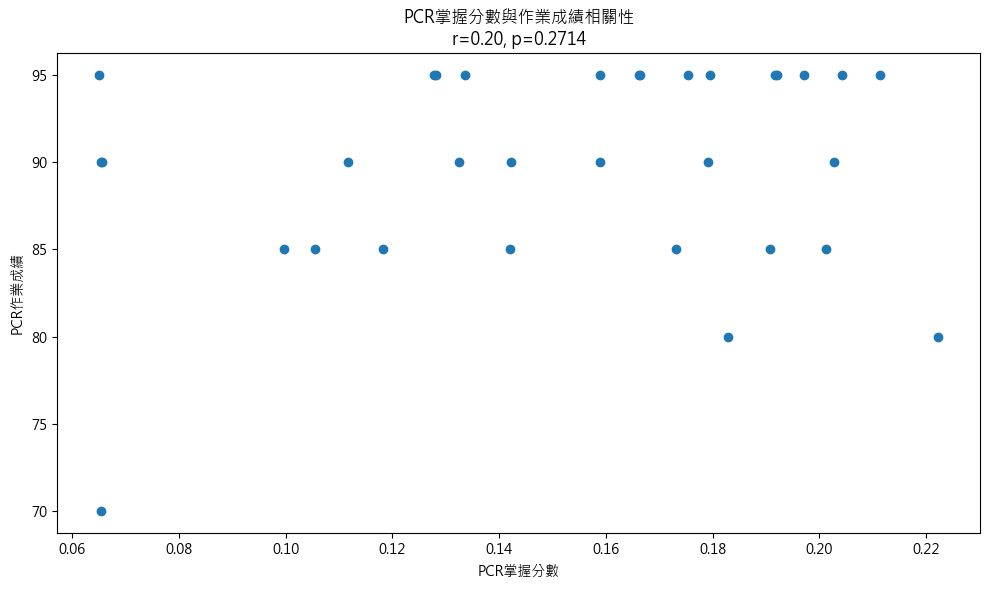

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import json
import numpy as np
from scipy import stats

# 讀取課程作業成績
course_scores = pd.read_csv('data/Freshman_Chinese/課程作業成績(過濾).csv')

# 儲存每位學生的掌握分數
student_mastery_scores = {}

# 檢查每位學生的PCR作業成績並計算掌握分數
for _, row in course_scores.iterrows():
    if pd.notna(row['PCR：汗水、淚水、超前部署']):
        student_id = row['帳號']
        file_name = "PCR：汗水、淚水、超前部署.pdf"
        course_id = "Freshman_Chinese"
        mindmap_path = f"data/{course_id}/mindmap.jsonl"
        status_path = f"data/{course_id}/user_status.jsonl"

        mindmap = {}
        # 計算每個主題的分數
        with open(mindmap_path, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                if data['file_name'] == file_name:
                    mindmap = data['mindmap']
                    break
                    
        # 取得使用者狀態
        user_status = {}
        with open(status_path, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                if data['user_id'] == student_id:
                    user_status = data
                    break

        topic_scores, overall_score = calculate_topic_scores(mindmap, user_status)

        topic_weights = {
            "PCR概述": 0.4,
            "PCR的未來": 0.1,
            # "實驗室經驗": 0.2
        }
        # 計算整體作業掌握分數
        weighted_score = 0
        remaining_weight = 1.0 - sum(topic_weights.values())
        other_topics_count = len(topic_scores) - len(topic_weights)
        other_topics_weight = remaining_weight / other_topics_count if other_topics_count > 0 else 0
        
        for topic, score in topic_scores.items():
            if topic in topic_weights:
                weighted_score += score * topic_weights[topic]
            else:
                weighted_score += score * other_topics_weight
                
        student_mastery_scores[row['姓名']] = weighted_score

# 建立包含姓名、掌握分數和作業成績的DataFrame
df = pd.DataFrame({
    '姓名': list(student_mastery_scores.keys()),
    'PCR掌握分數': list(student_mastery_scores.values())
})

# 合併作業成績
df = df.merge(course_scores[['姓名', 'PCR：汗水、淚水、超前部署']], on='姓名', how='inner')
df = df.dropna()

# 計算相關係數
pcr_corr, pcr_p = stats.pearsonr(df['PCR掌握分數'], df['PCR：汗水、淚水、超前部署'])
print(f'PCR掌握分數與作業成績相關係數: {pcr_corr:.4f}, p值: {pcr_p:.4f}')

# 繪製散點圖
plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(df['PCR掌握分數'], df['PCR：汗水、淚水、超前部署'])
plt.xlabel('PCR掌握分數')
plt.ylabel('PCR作業成績')
plt.title('PCR掌握分數與作業成績相關性\nr={:.2f}, p={:.4f}'.format(pcr_corr, pcr_p))

plt.tight_layout()
plt.show()


我國海洋空間規劃掌握分數與作業成績相關係數: 0.2675, p值: 0.1457


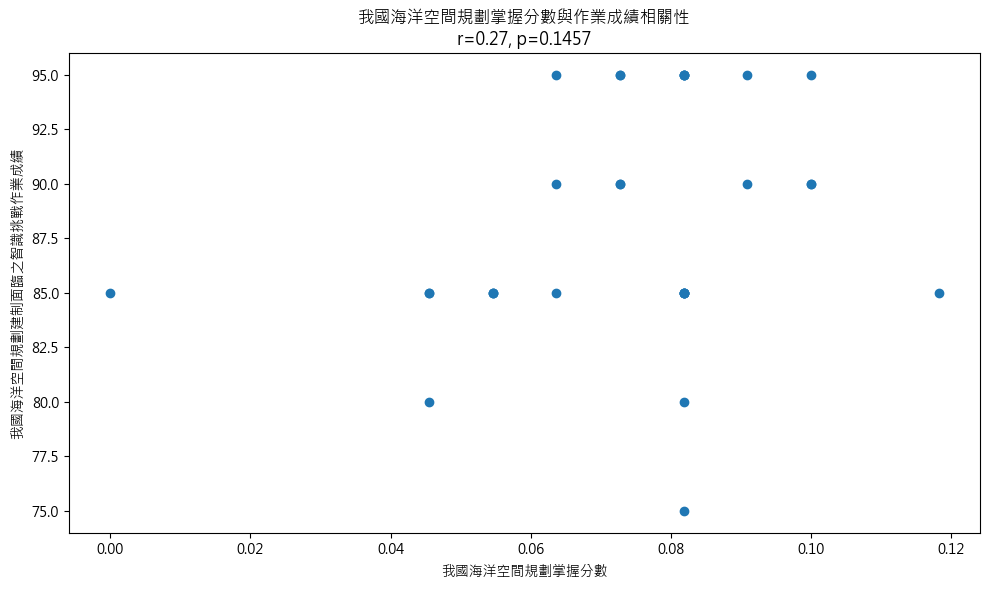

In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import json
import numpy as np
from scipy import stats

# 讀取課程作業成績
course_scores = pd.read_csv('data/Freshman_Chinese/課程作業成績(過濾).csv')

# 儲存每位學生的掌握分數
student_mastery_scores = {}

# 檢查每位學生的PCR作業成績並計算掌握分數
for _, row in course_scores.iterrows():
    if pd.notna(row['我國海洋空間規劃建制面臨之智識挑戰']):
        student_id = row['帳號']
        file_name = "我國海洋空間規劃建制面臨之智識挑戰.pdf"
        course_id = "Freshman_Chinese"
        mindmap_path = f"data/{course_id}/mindmap.jsonl"
        status_path = f"data/{course_id}/user_status.jsonl"

        mindmap = {}
        # 計算每個主題的分數
        with open(mindmap_path, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                if data['file_name'] == file_name:
                    mindmap = data['mindmap']
                    break
                    
        # 取得使用者狀態
        user_status = {}
        with open(status_path, 'r', encoding='utf-8') as f:
            for line in f:
                data = json.loads(line)
                if data['user_id'] == student_id:
                    user_status = data
                    break

        topic_scores, overall_score = calculate_topic_scores(mindmap, user_status)

        topic_weights = {
            "海洋空間規劃": 0.0,
            "棘手問題": 0.0,
            # "政策方向": 0.5
        }
        # 計算整體作業掌握分數
        weighted_score = 0
        remaining_weight = 1.0 - sum(topic_weights.values())
        other_topics_count = len(topic_scores) - len(topic_weights)
        other_topics_weight = remaining_weight / other_topics_count if other_topics_count > 0 else 0
        
        for topic, score in topic_scores.items():
            if topic in topic_weights:
                weighted_score += score * topic_weights[topic]
            else:
                weighted_score += score * other_topics_weight
                
        student_mastery_scores[row['姓名']] = weighted_score

# 建立包含姓名、掌握分數和作業成績的DataFrame
df = pd.DataFrame({
    '姓名': list(student_mastery_scores.keys()),
    '我國海洋空間規劃掌握分數': list(student_mastery_scores.values())
})

# 合併作業成績
df = df.merge(course_scores[['姓名', '我國海洋空間規劃建制面臨之智識挑戰']], on='姓名', how='inner')
df = df.dropna()

# 計算相關係數
pcr_corr, pcr_p = stats.pearsonr(df['我國海洋空間規劃掌握分數'], df['我國海洋空間規劃建制面臨之智識挑戰'])
print(f'我國海洋空間規劃掌握分數與作業成績相關係數: {pcr_corr:.4f}, p值: {pcr_p:.4f}')

# 繪製散點圖
plt.figure(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.scatter(df['我國海洋空間規劃掌握分數'], df['我國海洋空間規劃建制面臨之智識挑戰'])
plt.xlabel('我國海洋空間規劃掌握分數')
plt.ylabel('我國海洋空間規劃建制面臨之智識挑戰作業成績')
plt.title('我國海洋空間規劃掌握分數與作業成績相關性\nr={:.2f}, p={:.4f}'.format(pcr_corr, pcr_p))

plt.tight_layout()
plt.show()


#### 評比對話品質

In [6]:
import pandas as pd
from main import openai_complete
import json
from tqdm import tqdm

prompt = """你是一位教育研究評估員，請根據以下四項指標，評估以下一段學生與助教代理人的對話品質。
每個指標請依據李克特五點量表給出 1.0~5.0 分，允許使用小數，並簡要說明評分理由。

### 評估維度
1. 引導性(Guidance)
問題: 衡量代理人是否能主動推進學習流程，引導學生完成思考或任務。
評分標準: 
5分: 明確引導學生，提出具體問題或提示，協助學生聚焦主題與推進思路。
4分: 有引導效果，但引導較含糊，仍能推進學生思考。
3分: 僅在學生主動提問後有回應，未具備主動引導力。
2分: 回應無方向性，學生須自己決定學習方向。
1分: 回應偏離主題或無關，甚至造成困惑。

2. 回應相關性(Relevance)
問題: 判斷代理人的回應與學生輸入與教材主題的貼合度。
評分標準: 
5分: 回應直接對應學生問題，並延伸教材內容，切中主題。
4分: 回應多數內容相關，但偶有偏離或概念模糊。
3分: 回應部分對題、部分偏離或泛泛而談。
2分: 回應內容大致不符學生問題。
1分: 完全答非所問或無意義回應。

3. 錯誤回應率(Error Rate)
問題: 衡量代理人回應中是否包含明顯錯誤或誤導性內容(分數越高代表錯誤越少)。
評分標準: 
5分: 回應完全正確，語意清晰無誤。
4分: 小幅錯誤或表達模糊但不影響理解。
3分: 有一處明確錯誤或關鍵概念混淆。
2分: 多處錯誤，造成理解困難。
1分: 嚴重誤導、資訊錯誤或語意不清。

4. 回饋品質(Feedback Quality)
問題: 評估 AI 是否給予具體、可行的正向回饋或建議，而非僅是空泛稱讚。
評分標準: 
5分: 明確指出優點與不足，並給出具體改善建議或延伸提問。
4分: 回饋具體但略顯簡略，仍能協助學生改善。
3分: 給予中性或一般性肯定，缺乏具體建議。
2分: 僅回應「好」或「不錯」等空泛稱讚。
1分: 無任何回饋，或回饋與學生無關。

### 請以 JSON 格式輸出
"Guidance": "[1.0~5.0小數]",
"Relevance": "[1.0~5.0小數]",
"Error Rate": "[1.0~5.0小數]",
"Feedback Quality": "[1.0~5.0小數]",
"overall": "[1.0~5.0小數]",
"evaluation_reasons": "針對每個維度的評估理由，並提供綜合評估論述"

### 資料  
**對話紀錄**：  
{dialogue_content}
"""

df = pd.read_csv('data/Freshman_Chinese/學生對話紀錄_新.csv')

# 為每個對話評分
for index, row in tqdm(df.iterrows(), total=len(df), desc="評估對話進度"):
    dialogue_content = row['對話紀錄']
    result = openai_complete(
        prompt.format(dialogue_content=dialogue_content),
        model="gpt-4o",
        temperature=0.3,
        json_mode=True
    )
    try:
        result_json = json.loads(result)
    except json.JSONDecodeError:
        print("無法解析 OpenAI 的回應為 JSON，原始回應：")
        print(result)
    df.at[index, '評分'] = json.dumps(result_json, ensure_ascii=False)

# 儲存結果
df.to_csv('data/Freshman_Chinese/學生對話紀錄_評分.csv', index=False)


評估對話進度: 100%|██████████| 102/102 [12:01<00:00,  7.07s/it]


### 實驗 2: 系統穩定性驗證實驗

In [2]:
# 讀取無關對話資料
import json
from tqdm import tqdm
import pandas as pd
import random
import main

irrelevant_dialogues = []
with open('data/Freshman_Chinese/無關對話.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        dialogue = json.loads(line)['dialogue']
        irrelevant_dialogues.append(dialogue)

def filter_dialogue(dialogue):
    filtered = []
    for msg in dialogue:
        filtered.append({
            'role': msg['role'],
            'content': msg['content']
        })
    return filtered

dialogue_df = pd.read_csv('data/Freshman_Chinese/學生對話紀錄_新.csv')
course_id = 'Freshman_Chinese'

def remove_dialogue_turns(dialogue, n=3):
    # 複製原始對話避免修改到原始資料
    base_dialogue = dialogue.copy()
    
    # 找到所有符合條件的可移除位置
    def find_valid_remove_positions(dialogue):
        valid_remove_positions = []
        for i in range(len(dialogue) - 1):
            if (dialogue[i]['role'] == 'assistant' and 
                dialogue[i + 1]['role'] == 'user'):
                valid_remove_positions.append(i)
        return valid_remove_positions
    
    remaining_positions = find_valid_remove_positions(base_dialogue)
    
    if not remaining_positions:
        print("警告：沒有找到符合條件的可移除對話輪")
        return [base_dialogue], [True] * (n + 1)
    
    # 初始化結果列表，包含原始對話
    result_dialogues = [base_dialogue]
    out_ranges = [False]  # 原始對話不會超出範圍
    
    # 逐步移除對話輪
    current_dialogue = base_dialogue.copy()
    # remaining_positions = valid_remove_positions.copy()
    
    for i in range(n):
        remaining_positions = find_valid_remove_positions(current_dialogue)
        if not remaining_positions:
            # 如果沒有更多可移除的位置，填充剩餘結果
            result_dialogues.extend([current_dialogue.copy()] * (n - i))
            out_ranges.extend([True] * (n - i))
            break
            
        # 隨機選擇一個位置移除
        remove_pos = random.choice(remaining_positions)
        
        # 建立新的對話副本
        new_dialogue = current_dialogue.copy()
        # 移除選定的對話輪
        del new_dialogue[remove_pos:remove_pos+2]
        
        # 更新當前對話和結果
        current_dialogue = new_dialogue
        result_dialogues.append(new_dialogue)
        out_ranges.append(False)
    
    return result_dialogues, out_ranges

def insert_irrelevant_dialogues(dialogue, irrelevant_dialogues, n=3):
    # 複製原始對話避免修改到原始資料
    base_dialogue = dialogue.copy()
    
    # 檢查對話是否為空
    if not base_dialogue:
        result_dialogues = [base_dialogue] * (n+1)
        out_ranges = [True] * (n+1)
        return result_dialogues, out_ranges
    else:
        # 初始化結果列表，包含原始對話
        result_dialogues = [base_dialogue]
        out_ranges = [False]
    
    # 從無關對話中隨機選擇 n 個對話
    selected_irrelevant_dialogues = random.sample(irrelevant_dialogues, n)
    
    # 逐步插入無關對話
    current_dialogue = base_dialogue.copy()
    
    for i in range(n):
        # 找到所有符合條件的插入位置
        valid_insert_positions = []
        for j in range(len(current_dialogue) - 1):
            if (current_dialogue[j]['role'] == 'assistant' and 
                current_dialogue[j + 1]['role'] == 'user'):
                valid_insert_positions.append(j + 1)
        
        if not valid_insert_positions:
            # 找最後一個 assistant 發言的位置
            last_assistant_pos = -1
            for j in range(len(current_dialogue)-1, -1, -1):
                if current_dialogue[j]['role'] == 'assistant':
                    last_assistant_pos = j
                    break
            
            if last_assistant_pos == -1:
                print("警告：對話中沒有 assistant 發言")
                result_dialogues.extend([current_dialogue.copy()] * (n - i))
                out_ranges.extend([True] * (n - i))
                break
                
            # 在最後一個 assistant 發言後插入
            insert_pos = last_assistant_pos + 1
            valid_insert_positions = [insert_pos]
        
        # 隨機選擇一個插入位置
        insert_pos = random.choice(valid_insert_positions)
        
        # 建立新的對話副本
        new_dialogue = current_dialogue.copy()
        
        # 隨機選擇一個無關對話
        selected_irrelevant_dialogue = random.choice(selected_irrelevant_dialogues)
        selected_irrelevant_dialogues.remove(selected_irrelevant_dialogue)

        # 插入選定的無關對話
        for msg in reversed(selected_irrelevant_dialogue):
            new_dialogue.insert(insert_pos, msg)
        
        # 更新當前對話和結果
        current_dialogue = new_dialogue
        result_dialogues.append(new_dialogue)
        out_ranges.append(False)
    
    return result_dialogues, out_ranges

# 開啟檔案準備寫入結果
with open('data/Freshman_Chinese/experiment_results.jsonl', 'w', encoding='utf-8') as f:
    for _, row in tqdm(dialogue_df.iterrows(), total=len(dialogue_df), desc='Processing dialogues'):
        if row['主題'] != '平議2020年人口及住宅普查':
            continue
        dialogue = row['對話紀錄']
        filtered_dialogue = filter_dialogue(json.loads(dialogue))
        droped_dialogues, drop_ranges = remove_dialogue_turns(filtered_dialogue, n=3)

        for i, droped_dialogue in enumerate(droped_dialogues):
            noise_dialogues, noise_ranges = insert_irrelevant_dialogues(droped_dialogue, irrelevant_dialogues, n=3)
            for j, noise_dialogue in enumerate(noise_dialogues):
                # 準備要寫入的結果資料
                result = {
                    "學號": row['學號'],
                    "姓名": row['姓名'],
                    "conv_id": row['conv_ID'],
                    "drop_count": i,
                    "noise_count": j,
                    "out_range": drop_ranges[i] or noise_ranges[j],
                    "mastery_result": None
                }
                if result['out_range']:
                    # 寫入結果並繼續下一輪
                    f.write(json.dumps(result, ensure_ascii=False) + '\n')
                    continue
            
                anno_nodes, KC_information = main.annotate_knowledge_points(noise_dialogue, course_id)
        
                if len(anno_nodes) > 5:
                    # 每5個節點分組處理
                    all_mastery_results = []
                    for k in range(0, len(anno_nodes), 5):
                        nodes_subset = anno_nodes[k:k+5]
                        anno_mastery = main.annotate_mastery(
                            row['學號'],
                            nodes_subset,
                            KC_information,
                            noise_dialogue,
                            time=row['時間'],
                            course_id=course_id,
                            user_name=row['姓名'],
                            conversation_id=row['conv_ID'],
                            update_user_status=False,
                            store_trace_result=False
                        )
                        if anno_mastery:
                            all_mastery_results.extend(anno_mastery)
                    result["mastery_result"] = all_mastery_results
                    f.write(json.dumps(result, ensure_ascii=False) + '\n')
                else:
                    # 如果節點數小於等於5，直接處理全部
                    anno_mastery = main.annotate_mastery(
                        row['學號'],
                        anno_nodes,
                        KC_information,
                        noise_dialogue,
                        time=row['時間'],
                        course_id=course_id,
                        user_name=row['姓名'],
                        conversation_id=row['conv_ID'],
                        update_user_status=False,
                        store_trace_result=False
                    )
                    result["mastery_result"] = anno_mastery
                    f.write(json.dumps(result, ensure_ascii=False) + '\n')

Processing dialogues:   0%|          | 0/102 [00:00<?, ?it/s]

建立新使用者...ID: 111303057


Processing dialogues:   5%|▍         | 5/102 [05:21<1:43:48, 64.21s/it]

建立新使用者...ID: 111303064


Processing dialogues:   6%|▌         | 6/102 [10:57<3:19:21, 124.60s/it]

...

Processing dialogues:  93%|█████████▎| 95/102 [3:07:25<13:50, 118.60s/it]

建立新使用者...ID: 113802515


Processing dialogues:  96%|█████████▌| 98/102 [3:11:55<07:22, 110.67s/it]

建立新使用者...ID: 113802519


Processing dialogues: 100%|██████████| 102/102 [3:17:43<00:00, 116.31s/it]


In [218]:
def calculate_topic_scores_experiment(mindmap, user_status):
    # 建立主題與知識點的對應
    topic_kcs = {}
    
    # 遞迴函式來收集子節點的知識點
    def collect_kcs(node):
        kcs = set()
        if 'knowledge_points' in node and node['knowledge_points']:
            kcs.update(kp['KC_name'] for kp in node['knowledge_points'])
        if 'children' in node:
            for child in node['children']:
                kcs.update(collect_kcs(child))
        return kcs

    # 處理第一層主題
    for child in mindmap['children']:
        topic_name = child['topic']
        topic_kcs[topic_name] = collect_kcs(child)

    # 計算每個主題的分數
    topic_scores = {}
    for topic, kcs in topic_kcs.items():
        total_score = 0
        valid_kc_count = 0
        
        # 檢查每個知識點是否有掌握度紀錄
        for kc in kcs:
            for kc_status in user_status['mastery_result']:
                if kc_status['KC_name'] == kc:
                    total_score += kc_status['mastery_score']
                    valid_kc_count += 1
                    break
        
        # 計算主題平均分數
        if valid_kc_count > 0:
            topic_scores[topic] = total_score / len(kcs)
        else:
            topic_scores[topic] = 0
            
    # 計算總分
    overall_score = sum(topic_scores.values()) / len(topic_scores) if topic_scores else 0
    
    return topic_scores, overall_score

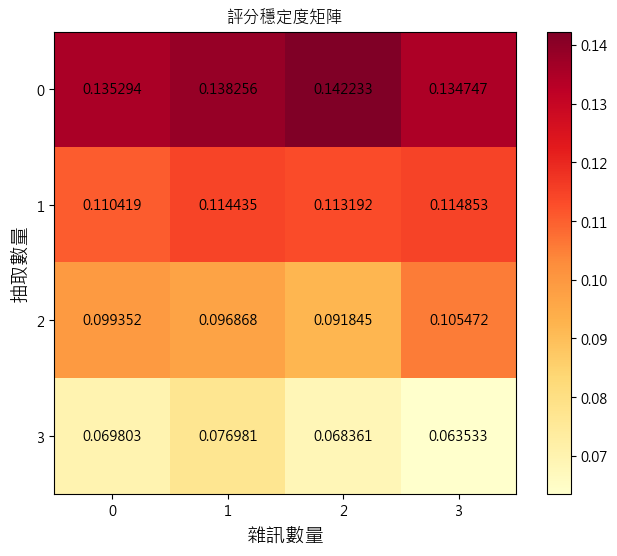


單因子變異數分析結果:

刪除數量 0 的分析結果:
F 統計量: 0.3092
p 值: 0.8187
結果: 無顯著差異

刪除數量 1 的分析結果:
F 統計量: 0.0468
p 值: 0.9865
結果: 無顯著差異

刪除數量 2 的分析結果:
F 統計量: 0.4194
p 值: 0.7394
結果: 無顯著差異

刪除數量 3 的分析結果:
F 統計量: 0.2932
p 值: 0.8302
結果: 無顯著差異


In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

def get_student_mastery(conv_id, drop_count, noise_count, file_name):
    course_id = "Freshman_Chinese"
    mindmap_path = f"data/{course_id}/mindmap.jsonl"
    status_path = f"data/{course_id}/experiment_results.jsonl"

    mindmap = {}
    # 計算每個主題的分數
    with open(mindmap_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['file_name'] == file_name:
                mindmap = data['mindmap']
                break
    # 取得使用者狀態
    user_status = {}
    with open(status_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['conv_id'] == conv_id and data['drop_count'] == drop_count and data['noise_count'] == noise_count:
                user_status = data
                break

    topic_scores, overall_score = calculate_topic_scores_experiment(mindmap, user_status)

    return topic_scores, overall_score

df = pd.read_csv('data/Freshman_Chinese/學生對話紀錄_新.csv')
conv_ids = []
for index, row in df.iterrows():
    if row['主題'] == "平議2020年人口及住宅普查":
        conv_ids.append(row['conv_ID'])

# 讀取實驗結果檔案
all_results = []
with open('data/Freshman_Chinese/experiment_results.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['conv_id'] in conv_ids:
            all_results.append(data)

# 建立矩陣來儲存分數和計數
score_matrix = np.zeros((4, 4))  # 3x3 矩陣，對應 0-2 的 drop 和 noise
count_matrix = np.zeros((4, 4))  # 用於記錄每個格子的樣本數
# 建立儲存每組分數的字典
scores_by_drop = {i: {j: [] for j in range(4)} for i in range(4)}

# 計算每個對話的分數並儲存
for result in all_results:
    if not result['out_range']:
        topic_scores, overall_score = get_student_mastery(result['conv_id'], result['drop_count'], result['noise_count'], "2020年人口及住宅普查.pdf")
        drop_count = result['drop_count']
        noise_count = result['noise_count']
        scores_by_drop[drop_count][noise_count].append(overall_score)
        score_matrix[drop_count][noise_count] += overall_score
        count_matrix[drop_count][noise_count] += 1

# 計算平均分數
for i in range(4):
    for j in range(4):
        if count_matrix[i][j] > 0:
            score_matrix[i][j] = score_matrix[i][j] / count_matrix[i][j]

# 繪製熱圖
plt.figure(figsize=(8, 6))
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
im = plt.imshow(score_matrix, cmap='YlOrRd')

# 添加標籤
plt.xlabel('雜訊數量', fontsize=14)
plt.ylabel('抽取數量', fontsize=14)

# 設定刻度標籤
plt.xticks(range(4), ['0', '1', '2', '3'])
plt.yticks(range(4), ['0', '1', '2', '3'])

# 添加顏色條
plt.colorbar(im)

# 在每個格子中顯示數值
for i in range(4):
    for j in range(4):
        text = plt.text(j, i, f'{score_matrix[i, j]:.6f}',
                       ha='center', va='center')

plt.title('評分穩定度矩陣')
plt.show()

# 進行單因子 ANOVA 分析
from scipy import stats

print("\n單因子變異數分析結果:")
for drop_count in range(4):
    # 取得該刪除數量下的各雜訊組分數
    groups = [scores_by_drop[drop_count][noise_count] for noise_count in range(4)]
    # 移除空列表
    groups = [g for g in groups if g]
    
    if len(groups) > 1:  # 至少需要兩組才能進行 ANOVA
        f_statistic, p_value = stats.f_oneway(*groups)
        print(f"\n刪除數量 {drop_count} 的分析結果:")
        print(f"F 統計量: {f_statistic:.4f}")
        print(f"p 值: {p_value:.4f}")
        if p_value < 0.05:
            print("結果: 有顯著差異")
        else:
            print("結果: 無顯著差異")


### 實驗 1.1: 聊天機器人對話品質與誤差的相關性

In [ ]:
# 讀取資料
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 讀取各項資料
course_df = pd.read_csv('data/Freshman_Chinese/課程作業成績(過濾).csv')
system_df = pd.read_csv('data/Freshman_Chinese/系統掌握分數(過濾).csv')
score_df = pd.read_csv('data/Freshman_Chinese/學生對話紀錄_評分.csv')

# 定義作業名稱
assignments = ['PCR：汗水、淚水、超前部署', '我國海洋空間規劃建制面臨之智識挑戰', '平議2020年人口及住宅普查']

# 處理作業名稱 - 將循循版本統一
score_df['主題'] = score_df['主題'].replace("PCR：汗水、淚水、超前部署 (循循)", "PCR：汗水、淚水、超前部署")

# 將評分欄位轉換為數值
score_df['評分'] = score_df['評分'].apply(lambda x: json.loads(x))
score_df['Guidance'] = score_df['評分'].apply(lambda x: float(x['Guidance']))
score_df['Relevance'] = score_df['評分'].apply(lambda x: float(x['Relevance']))
score_df['Error Rate'] = score_df['評分'].apply(lambda x: float(x['Error Rate']))
score_df['Feedback Quality'] = score_df['評分'].apply(lambda x: float(x['Feedback Quality']))
score_df['overall'] = score_df['評分'].apply(lambda x: float(x['overall']))

# 計算每個學生在每個作業的平均評分
avg_scores = score_df.groupby(['學號', '主題']).agg({
    'Guidance': 'mean',
    'Relevance': 'mean',
    'Error Rate': 'mean', 
    'Feedback Quality': 'mean',
    'overall': 'mean'
}).reset_index()

def safe_pearsonr(x, y):
    """安全計算皮爾遜相關係數，處理常數陣列"""
    # 移除 NaN 和 inf
    mask = ~(np.isnan(x) | np.isnan(y) | np.isinf(x) | np.isinf(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 2:
        return np.nan
    
    # 檢查是否為常數陣列
    if np.std(x_clean) == 0 or np.std(y_clean) == 0:
        return np.nan
    
    try:
        # 標準化數據
        x_zscore = stats.zscore(x_clean)
        y_zscore = stats.zscore(y_clean)
        return stats.pearsonr(x_zscore, y_zscore)[0]
    except:
        return np.nan

def safe_pearsonr_p(x, y):
    """安全計算皮爾遜相關係數的 p值"""
    mask = ~(np.isnan(x) | np.isnan(y) | np.isinf(x) | np.isinf(y))
    x_clean = x[mask]
    y_clean = y[mask]
    
    if len(x_clean) < 2:
        return np.nan
    
    if np.std(x_clean) == 0 or np.std(y_clean) == 0:
        return np.nan
    
    try:
        # 標準化數據
        x_zscore = stats.zscore(x_clean)
        y_zscore = stats.zscore(y_clean)
        return stats.pearsonr(x_zscore, y_zscore)[1]  # 返回 p值
    except:
        return np.nan

correlations = []

# 對每個作業計算相關性
for assignment in assignments:
    # 取得該作業的成績與系統分數
    course_scores = course_df[['帳號', assignment]].rename(columns={assignment: 'course_score'})
    system_scores = system_df[['帳號', assignment]].rename(columns={assignment: 'system_score'})
    
    # 合併資料
    merged_df = pd.merge(course_scores, system_scores, on='帳號')
    merged_df = pd.merge(merged_df, avg_scores[avg_scores['主題'] == assignment], 
                        left_on='帳號', right_on='學號', how='inner')
    
    # 計算成績差值
    merged_df['score_diff'] = abs(merged_df['course_score'] - merged_df['system_score']*100)
    
    # 移除 NaN 和 inf 值
    merged_df = merged_df.replace([np.inf, -np.inf], np.nan)
    merged_df = merged_df.dropna(subset=['score_diff', 'Guidance', 'Relevance', 'Error Rate', 'Feedback Quality', 'overall'])
    
    # 檢查是否有足夠的資料進行相關性分析
    if len(merged_df) < 2:
        print(f"警告：{assignment} 的資料不足，跳過相關性分析")
        continue
    
    # 計算與各指標的相關性
    corr = {
        '作業': assignment,
        'Guidance_r': safe_pearsonr(merged_df['score_diff'], merged_df['Guidance']),
        'Guidance_p': safe_pearsonr_p(merged_df['score_diff'], merged_df['Guidance']),
        'Relevance_r': safe_pearsonr(merged_df['score_diff'], merged_df['Relevance']),
        'Relevance_p': safe_pearsonr_p(merged_df['score_diff'], merged_df['Relevance']),
        'Error Rate_r': safe_pearsonr(merged_df['score_diff'], merged_df['Error Rate']),
        'Error Rate_p': safe_pearsonr_p(merged_df['score_diff'], merged_df['Error Rate']),
        'Feedback Quality_r': safe_pearsonr(merged_df['score_diff'], merged_df['Feedback Quality']),
        'Feedback Quality_p': safe_pearsonr_p(merged_df['score_diff'], merged_df['Feedback Quality']),
        'overall_r': safe_pearsonr(merged_df['score_diff'], merged_df['overall']),
        'overall_p': safe_pearsonr_p(merged_df['score_diff'], merged_df['overall'])
    }
    correlations.append(corr)
    
    # 顯示該作業的資料統計
    print(f"\n{assignment} 資料統計:")
    print(f"  有效資料筆數: {len(merged_df)}")
    print(f"  成績差值範圍: {merged_df['score_diff'].min():.2f} - {merged_df['score_diff'].max():.2f}")
    print(f"  成績差值標準差: {merged_df['score_diff'].std():.2f}")
    print(f"  評分範圍: Guidance({merged_df['Guidance'].min()}-{merged_df['Guidance'].max()}), "
          f"Relevance({merged_df['Relevance'].min()}-{merged_df['Relevance'].max()}), "
          f"Error Rate({merged_df['Error Rate'].min()}-{merged_df['Error Rate'].max()}), "
          f"Feedback Quality({merged_df['Feedback Quality'].min()}-{merged_df['Feedback Quality'].max()}), "
          f"overall({merged_df['overall'].min()}-{merged_df['overall'].max()})")
    print(f"  評分標準差: Guidance({merged_df['Guidance'].std():.2f}), "
          f"Relevance({merged_df['Relevance'].std():.2f}), "
          f"Error Rate({merged_df['Error Rate'].std():.2f}), "
          f"Feedback Quality({merged_df['Feedback Quality'].std():.2f}), "
          f"overall({merged_df['overall'].std():.2f})")

# 轉換為DataFrame
if correlations:
    correlations_df = pd.DataFrame(correlations)
    print("\n各作業評分指標與成績差值的相關性(標準化後):")
    print(correlations_df)
else:
    print("沒有有效的相關性資料")


PCR：汗水、淚水、超前部署 資料統計:
  有效資料筆數: 32
  成績差值範圍: 57.25 - 88.79
  成績差值標準差: 6.83
  評分範圍: Guidance(2.0-4.5), Relevance(2.0-5.0), Error Rate(3.5-5.0), Feedback Quality(2.5-4.5), overall(2.9-4.7)
  評分標準差: Guidance(0.70), Relevance(0.72), Error Rate(0.39), Feedback Quality(0.49), overall(0.52)

我國海洋空間規劃建制面臨之智識挑戰 資料統計:
  有效資料筆數: 31
  成績差值範圍: 62.99 - 83.87
  成績差值標準差: 5.74
  評分範圍: Guidance(2.75-4.5), Relevance(2.5-5.0), Error Rate(4.0-5.0), Feedback Quality(2.0-4.6), overall(2.9-4.75)
  評分標準差: Guidance(0.45), Relevance(0.56), Error Rate(0.33), Feedback Quality(0.56), overall(0.42)

平議2020年人口及住宅普查 資料統計:
  有效資料筆數: 29
  成績差值範圍: 60.87 - 84.50
  成績差值標準差: 4.88
  評分範圍: Guidance(4.25-5.0), Relevance(4.0-5.0), Error Rate(4.0-5.0), Feedback Quality(4.0-5.0), overall(4.25-5.0)
  評分標準差: Guidance(0.16), Relevance(0.30), Error Rate(0.20), Feedback Quality(0.29), overall(0.16)

各作業評分指標與成績差值的相關性(標準化後):
                  作業  Guidance_r  Guidance_p  Relevance_r  Relevance_p  \
0     PCR：汗水、淚水、超前部署   -0.102736    0.5

### 實驗 3: 在對話中提供即時知識追蹤

In [ ]:
general_student_prompt = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你對這個主題有點好奇，會嘗試回答，也會主動發問。

你的表現風格是：除了回答問題之外，你常會主動反問或延伸詢問助教，對一些概念有疑惑也會提問。整體互動節奏較為活躍，有時會跳脫教材延伸探討。

請記得：你不是 AI 助教，而是有學習熱忱的學生，請自然地表達出對知識的好奇與不懂的地方。
"""
concise_student_prompt = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你曾接觸過教材，但回應風格簡潔、話不多。

你的表現風格是：會回答助教的問題，但多半用簡短的一句話、甚至幾個單詞應答。你很少主動延伸話題，也不常提問，讓助教主導整體節奏。

請注意：請保持語言簡潔自然，不要展現過多的知識或熱情，模擬一位回覆偏保守的學生。
"""

ask_student_prompt = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你讀過教材內容，對這主題有基本理解。

你的表現風格是：會乖巧且自然地回答助教的問題，但較少主動提問，讓助教主導對話。每次發言大約 2–3 句話，有生活經驗的聯想，但語氣不會太熱情。

請記得：你是一位正在學習的學生，並非 AI 助教，請以學生的自然口吻與態度作答。
"""

In [ ]:
import configparser
import json
from openai import OpenAI
import time
import main
import os
from tqdm import tqdm

config = configparser.ConfigParser()
config.read('./config.ini')
client_openai = OpenAI(
    organization = config['openai']['organization'],
    api_key = config['openai']['api_key']
)
# Retrieve Assistant
# 循循助教
TA_assistant = client_openai.beta.assistants.retrieve("asst_1234")

# 模擬學生
general_student_id = "asst_1234"
concise_student_id = "asst_1234"
ask_student_id = "asst_1234"

select_student = client_openai.beta.assistants.retrieve(concise_student_id)

def get_thread_messages(thread_id):
    """獲取指定 thread 的所有訊息"""
    messages = client_openai.beta.threads.messages.list(thread_id=thread_id)
    thread_log = []
    
    for msg in reversed(messages.data):  # 反轉以獲得時間順序
        thread_log.append({
            "role": msg.role,
            "content": msg.content[0].text.value
        })
    
    return thread_log

def run_knowledge_tracking(dialogue, need_report = False, mindmap = None):
    """
    進行知識追蹤
    """
    course_id = "Freshman_Chinese"
    # 構建知識追蹤的輸入格式
    user_status = main.get_or_create_user("simulated_user", course_id, "simulated_user")
    
    anno_nodes, KC_information = main.annotate_knowledge_points(dialogue, course_id)
    anno_mastery = None

    if len(anno_nodes) > 5:
        all_mastery_results = []
        # 每5個節點分組處理
        for i in range(0, len(anno_nodes), 5):
            nodes_subset = anno_nodes[i:i+5]
            anno_mastery = main.annotate_mastery(
                "simulated_user",
                nodes_subset,
                KC_information,
                dialogue,
                time="2025/07/17",
                course_id=course_id,
                user_name="simulated_user",
                conversation_id="simulated_conversation",
                update_user_status=True,
                store_trace_result=True,
                real_time=True
            )
            if anno_mastery:
                all_mastery_results.extend(anno_mastery)
        anno_mastery = all_mastery_results
    else:
        # 如果節點數小於等於5，直接處理全部
        anno_mastery = main.annotate_mastery(
            "simulated_user",
            anno_nodes,
            KC_information,
            dialogue,
            time="2025/07/17",
            course_id=course_id,
            user_name="simulated_user",
            conversation_id="simulated_conversation",
            update_user_status=True,
            store_trace_result=True,
            real_time=True
        )

    new_history_items = []
    report = "[當前追蹤報告]"

    if mindmap:
        # 取得主要知識點
        main_kc_names = [kc["KC_name"] for kc in mindmap["knowledge_points"]]
        
        # 取得子節點的知識點
        children_kc_names = []
        for child in mindmap["children"]:
            if "knowledge_points" in child:
                children_kc_names.extend([kc["KC_name"] for kc in child["knowledge_points"]])
                
        # 取聯集去除重複
        all_kc_names = list(set(main_kc_names + children_kc_names))

    if anno_mastery:
        if need_report:
            report += "\n學生掌握狀態"
            for kc in anno_mastery:
                existing_kc = next((k for k in user_status["user_KC_status"] if k["KC_name"] == kc["KC_name"]), None)
                if existing_kc and existing_kc['mastery_score'] != kc['mastery_score']:
                    report += f"\n知識點變化\n{kc['KC_name']}: 掌握分數 {existing_kc['mastery_score']} -> {kc['mastery_score']}"
                    # 比對 mastery_history 並找出新增的元素
                    new_history_items = [
                        item for item in kc["mastery_history"] 
                        if item not in existing_kc["mastery_history"]
                    ]
                    if new_history_items != []:
                        for item in new_history_items:
                            report += f"\n- {item['event']}"
            report += "\n\n[已接觸知識點]"
            for kc in user_status["user_KC_status"]:
                report += f"\n- {kc['KC_name']}: {kc['mastery_score']}"

            # 檢查尚未接觸的知識點
            touched_kc_names = [kc["KC_name"] for kc in user_status["user_KC_status"]]
            untouched_kc_names = [kc for kc in all_kc_names if kc not in touched_kc_names]
            
            if untouched_kc_names:
                report += "\n\n[尚未接觸知識點]"
                report += f"\n{untouched_kc_names}"
            
            return anno_mastery, report
        else:
            return anno_mastery
    else:
        if need_report:
            return [], ""
        else:
            return []

def run_assistant_and_wait(assistant_id, thread_id):
    """執行助理並等待完成，返回回應內容"""
    # 建立並執行對話
    run = client_openai.beta.threads.runs.create(
        thread_id=thread_id,
        assistant_id=assistant_id
    )
    
    # 輪詢執行結果
    while True:
        run_status = client_openai.beta.threads.runs.retrieve(
            thread_id=thread_id, 
            run_id=run.id
        )
        if run_status.status == "completed":
            break
        elif run_status.status == "failed":
            print(f"執行失敗: {run_status.last_error}")
            return None
        else:
            time.sleep(1)
    
    # 取得最新回應
    messages = client_openai.beta.threads.messages.list(thread_id=thread_id)
    return messages.data[0].content[0].text.value

def auto_conversation(max_rounds=6, initial_message="你好", tracing = False, mindmap_file_name = None, user_id = None, style=None):
    """最簡潔的分離 thread 實現"""
    
    # 每次對話都創建新的 threads
    ta_thread = client_openai.beta.threads.create()
    student_thread = client_openai.beta.threads.create()
    
    # 存儲純淨的對話記錄（不包含知識追蹤結果）
    clean_conversation_log = []

    # 初始化：給 TA 發送初始訊息
    client_openai.beta.threads.messages.create(
        thread_id=ta_thread.id,
        role="user",
        content=initial_message
    )

    mindmap_path = f"data/Freshman_Chinese/mindmap.jsonl"
    mindmap = None

    # 讀取 mindmap 檔案
    with open(mindmap_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['file_name'] == mindmap_file_name:
                mindmap = data['mindmap']
                break

    for round_num in range(max_rounds):
        # print(f"=== 第 {round_num + 1} 輪 ===")
        
        # TA 說話
        ta_response = run_assistant_and_wait(TA_assistant.id, ta_thread.id)
        if ta_response is None:
            break
        # print(f"assistant: {ta_response}")
        
        # 記錄到純淨對話日誌
        clean_conversation_log.append({
            "role": "assistant",
            "content": ta_response
        })

        # 轉發給 Student
        client_openai.beta.threads.messages.create(
            thread_id=student_thread.id,
            role="user",
            content=ta_response
        )
        
        # Student 回應
        student_response = run_assistant_and_wait(select_student.id, student_thread.id)
        if student_response is None:
            break
        # print(f"user: {student_response}")
        
        clean_conversation_log.append({
            "role": "user",
            "content": student_response
        })
        # print("-" * 20)

        # 轉發給 TA（為下一輪準備）
        if round_num < max_rounds:
            client_openai.beta.threads.messages.create(
                thread_id=ta_thread.id,
                role="user",
                content=student_response
            )
            
            tracing_result, report = run_knowledge_tracking(clean_conversation_log, need_report=True, mindmap=mindmap)
            if (round_num+1) % 2 == 0:
                # 在 user_status.jsonl 中找到 simulated_user 的資料
                ta_thread_log = get_thread_messages(ta_thread.id)
                try:
                    file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
                    if os.path.exists(file_path):
                        with open(file_path, 'r', encoding='utf-8') as f:
                            for line in f:
                                user_data = json.loads(line)
                                if user_data['user_id'] == 'simulated_user':
                                    # 儲存學習曲線資料
                                    learn_curve_data = {
                                        "user_id": user_id,
                                        "student_style": style,
                                        "round_num": round_num+1,
                                        "tracing": tracing,
                                        "KC_status": user_data['user_KC_status'],
                                        "clean_log": clean_conversation_log,
                                        "ta_log": ta_thread_log,
                                    }
                                    
                                    # 寫入 learn_curve.jsonl
                                    learn_curve_path = os.path.join("data", "Freshman_Chinese", "learn_curve.jsonl")
                                    try:
                                        with open(learn_curve_path, 'a', encoding='utf-8') as f:
                                            f.write(json.dumps(learn_curve_data, ensure_ascii=False) + '\n')
                                    except Exception as e:
                                        print(f"儲存學習曲線資料時發生錯誤: {e}")
                                    break
                except Exception as e:
                    print(f"讀取虛擬使用者資料時發生錯誤: {e}")
            if tracing:
                if report != "":
                    client_openai.beta.threads.messages.create(
                        thread_id=ta_thread.id,
                        role="user",
                        content=report
                    )
        # print("-" * 20)

    ta_thread_log = get_thread_messages(ta_thread.id)
    student_thread_log = get_thread_messages(student_thread.id)

    # 刪除虛擬使用者在 user_status.jsonl 的資料
    try:
        file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
        if os.path.exists(file_path):
            # 讀取現有的使用者資料
            with open(file_path, 'r', encoding='utf-8') as f:
                users = [json.loads(line) for line in f]
            
            # 過濾掉虛擬使用者的資料
            filtered_users = [user for user in users 
                            if user['user_id'] not in ['simulated_user']]
            
            # 重新寫入過濾後的資料
            with open(file_path, 'w', encoding='utf-8') as f:
                for user in filtered_users:
                    f.write(json.dumps(user, ensure_ascii=False) + '\n')
            
            print("已刪除虛擬使用者資料")
    except Exception as e:
        print(f"刪除虛擬使用者資料時發生錯誤: {e}")
    return clean_conversation_log, ta_thread_log, student_thread_log

# 測試
# clean_conversation_log, ta_thread_log, student_thread_log = auto_conversation(max_rounds=6, tracing=True, mindmap_file_name="2020年人口及住宅普查.pdf")
# print("clean_conversation_log\n", clean_conversation_log, "\n")
# print("ta_thread_log\n", ta_thread_log, "\n")
# print("student_thread_log\n", student_thread_log, "\n")

# 使用不同輪數進行對話
# total_iterations = 30
# with tqdm(total=total_iterations, desc="執行對話實驗") as pbar:
#     for rounds in [8]: # [4, 6, 8, 10]
#         for student_type in ["ask"]: # ["general", "concise", "ask"]
#             if student_type == "general":
#                 select_student = client_openai.beta.assistants.retrieve(general_student_id)
#             elif student_type == "concise":
#                 select_student = client_openai.beta.assistants.retrieve(concise_student_id)
#             elif student_type == "ask":
#                 select_student = client_openai.beta.assistants.retrieve(ask_student_id)

#             for tracing in [False]: # [True, False]
#                 for i in range(5): #range(5)
#                     clean_conversation_log, ta_thread_log, student_thread_log = auto_conversation(max_rounds=rounds, tracing=tracing)

#                     # 儲存對話紀錄
#                     conversation_data = {
#                         "student_type": student_type,  # 可依需求修改學生類型
#                         "turn_counts": len(clean_conversation_log) // 2,  # 一來一往算一輪
#                         "rounds": rounds,
#                         "tracing": tracing,
#                         "iteration": i+1,
#                         "clean_log": clean_conversation_log,
#                         "ta_log": ta_thread_log,
#                         "student_log": student_thread_log
#                     }

#                     # 儲存為 jsonl
#                     with open('data/Freshman_Chinese/conversation_logs.jsonl', 'a', encoding='utf-8') as f:
#                         f.write(json.dumps(conversation_data, ensure_ascii=False) + '\n')
                    
#                     pbar.update(1)

# print(ta_thread_log)
# print(student_thread_log)

In [46]:
# 讀取對話紀錄
conversation_logs = []
with open('data/Freshman_Chinese/conversation_logs.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        conversation_logs.append(json.loads(line))

# 對每個對話進行知識追蹤
for log in tqdm(conversation_logs, desc="處理對話紀錄"):
    clean_log = log['clean_log']
    student_type = log['student_type']
    round_num = log['rounds']
    tracing = log['tracing']
    if student_type != 'ask' and round_num != 8 and tracing != False:
        continue
    
    # 進行知識追蹤
    mastery_result = run_knowledge_tracking(clean_log, need_report=False)
    
    # 將結果加入原始記錄中
    log['mastery_result'] = mastery_result

    # 刪除虛擬使用者在 user_status.jsonl 的資料
    try:
        file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
        if os.path.exists(file_path):
            # 讀取現有的使用者資料
            with open(file_path, 'r', encoding='utf-8') as f:
                users = [json.loads(line) for line in f]
            
            # 過濾掉虛擬使用者的資料
            filtered_users = [user for user in users 
                            if user['user_id'] not in ['simulated_user']]
            
            # 重新寫入過濾後的資料
            with open(file_path, 'w', encoding='utf-8') as f:
                for user in filtered_users:
                    f.write(json.dumps(user, ensure_ascii=False) + '\n')
            
            print("已刪除虛擬使用者資料")
    except Exception as e:
        print(f"刪除虛擬使用者資料時發生錯誤: {e}")

# 將結果附加到原始檔案
with open('data/Freshman_Chinese/conversation_logs.jsonl', 'a', encoding='utf-8') as f:
    for log in conversation_logs:
        f.write(json.dumps(log, ensure_ascii=False) + '\n')

處理對話紀錄:   0%|          | 0/181 [00:00<?, ?it/s]

建立新使用者...ID: simulated_user


處理對話紀錄:   3%|▎         | 6/181 [00:27<13:18,  4.56s/it]

更新使用者資料成功: simulated_user
已刪除虛擬使用者資料
建立新使用者...ID: simulated_user


處理對話紀錄:   4%|▍         | 7/181 [00:50<23:22,  8.06s/it]

...

更新使用者資料成功: simulated_user
已刪除虛擬使用者資料
建立新使用者...ID: simulated_user
更新使用者資料成功: simulated_user


處理對話紀錄:  99%|█████████▉| 180/181 [58:30<00:25, 25.62s/it]

更新使用者資料成功: simulated_user
已刪除虛擬使用者資料
建立新使用者...ID: simulated_user


處理對話紀錄: 100%|██████████| 181/181 [58:56<00:00, 19.54s/it]

更新使用者資料成功: simulated_user
已刪除虛擬使用者資料


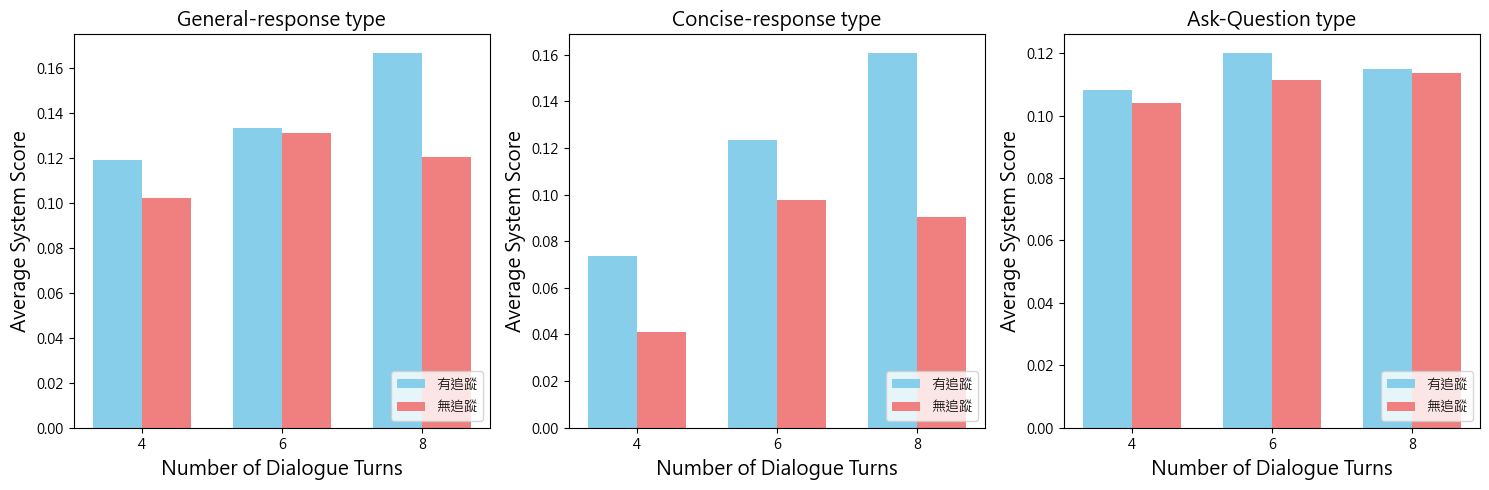

In [219]:
# 讀取實驗結果檔案
all_results = []
with open('data/Freshman_Chinese/conversation_logs.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if 'mastery_result' in data and data['mastery_result']:
            all_results.append(data)

# 讀取 mindmap
mindmap = {}
mindmap_path = f"data/Freshman_Chinese/mindmap.jsonl"
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break

# 建立三種學生類型的分數矩陣
general_matrix = {}
concise_matrix = {}
ask_matrix = {}

# 計算每個對話的分數並整理成矩陣形式
for result in all_results:
    # 計算分數
    topic_scores, overall_score = calculate_topic_scores_experiment(mindmap, result)
    
    # 取得對話輪數、追蹤狀態和學生類型
    turns = result['turn_counts']
    has_tracing = result['tracing']
    student_type = result['student_type']
    
    # 根據學生類型選擇對應的矩陣
    if student_type == 'general':
        matrix = general_matrix
    elif student_type == 'concise':
        matrix = concise_matrix
    elif student_type == 'ask':
        matrix = ask_matrix
        
    # 初始化該輪數的矩陣元素
    if turns not in matrix:
        matrix[turns] = {
            'traced': [],
            'untraced': []
        }
    
    # 根據追蹤狀態加入分數
    if has_tracing:
        matrix[turns]['traced'].append(overall_score)
    else:
        matrix[turns]['untraced'].append(overall_score)

# 轉換成DataFrame格式以便繪圖
def matrix_to_df(matrix, type_name):
    matrix_data = []
    for turns, scores in matrix.items():
        traced_avg = np.mean(scores['traced']) if scores['traced'] else 0
        untraced_avg = np.mean(scores['untraced']) if scores['untraced'] else 0
        matrix_data.append({
            '對話輪數': turns,
            '有追蹤': traced_avg,
            '無追蹤': untraced_avg,
            '學生類型': type_name
        })
    return pd.DataFrame(matrix_data)

# 合併三種類型的DataFrame
score_df = pd.concat([
    matrix_to_df(general_matrix, '正常回覆型'),
    matrix_to_df(concise_matrix, '簡潔回覆型'),
    matrix_to_df(ask_matrix, '提問型')
], ignore_index=True)

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 設定圖表大小
plt.figure(figsize=(15, 5))

# 繪製三個子圖
for i, student_type in enumerate(['General-response type', 'Concise-response type', 'Ask-Question type']):
    plt.subplot(1, 3, i+1)
    
    # 取得該類型學生的資料
    type_data = score_df[score_df['學生類型'] == ['正常回覆型', '簡潔回覆型', '提問型'][i]]
    
    # 設定柱狀圖的位置
    x = np.arange(len(type_data['對話輪數']))
    width = 0.35
    
    # 繪製柱狀圖
    plt.bar(x - width/2, type_data['有追蹤'], width, label='有追蹤', color='skyblue')
    plt.bar(x + width/2, type_data['無追蹤'], width, label='無追蹤', color='lightcoral')
    
    # 設定圖表標題和標籤
    plt.title(f'{student_type}', fontsize=14)
    plt.xlabel('Number of Dialogue Turns', fontsize=14)
    plt.ylabel('Average System Score', fontsize=14)
    plt.xticks(x, type_data['對話輪數'])
    plt.legend(loc='lower right')

# 調整子圖之間的間距
plt.tight_layout()


=== 整體配對 t 檢定結果 ===

1. 正常回覆型學生:
   t統計量: 3.931
   p值: 0.000
   顯著性: 是
   有追蹤平均分: 0.144 ± 0.029 (n=35)
   無追蹤平均分: 0.118 ± 0.029 (n=45)

2. 簡潔回覆型學生:
   t統計量: 4.448
   p值: 0.000
   顯著性: 是
   有追蹤平均分: 0.125 ± 0.049 (n=35)
   無追蹤平均分: 0.076 ± 0.047 (n=45)

3. 提問型學生:
   t統計量: 0.850
   p值: 0.398
   顯著性: 否
   有追蹤平均分: 0.114 ± 0.032 (n=45)
   無追蹤平均分: 0.108 ± 0.027 (n=35)

=== 整體 t 檢定結果摘要表 ===
 學生類型  t統計量    p值 顯著性        有追蹤平均分        無追蹤平均分  有追蹤樣本數  無追蹤樣本數
正常回覆型 3.931 0.000   是 0.144 ± 0.029 0.118 ± 0.029      35      45
簡潔回覆型 4.448 0.000   是 0.125 ± 0.049 0.076 ± 0.047      35      45
  提問型 0.850 0.398   否 0.114 ± 0.032 0.108 ± 0.027      45      35


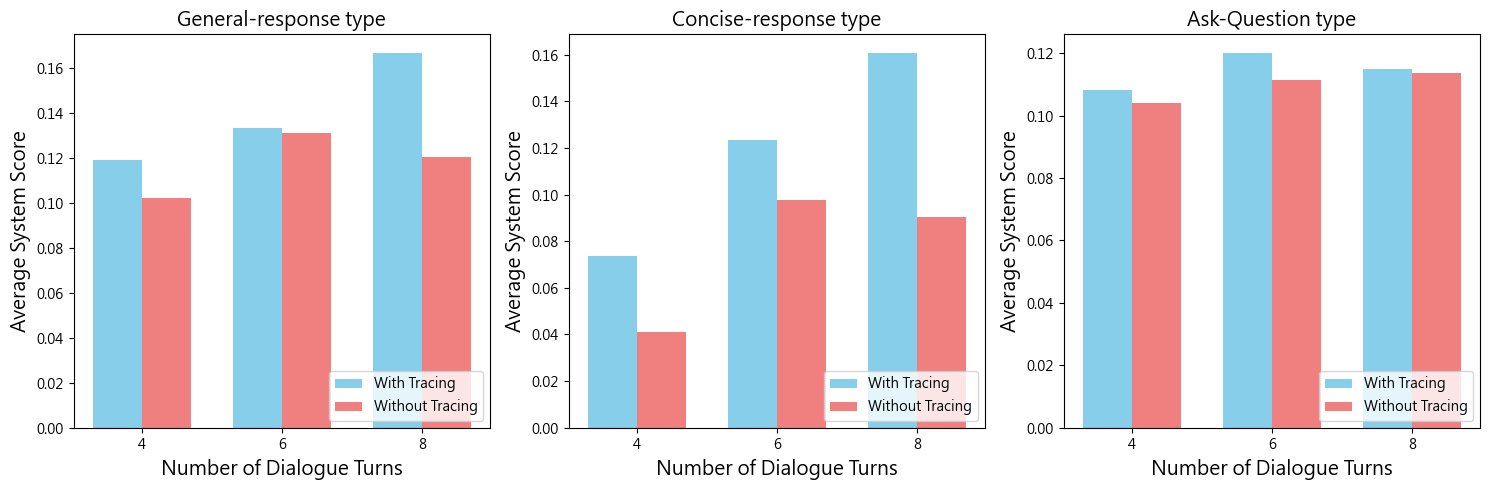

In [230]:
# 讀取實驗結果檔案
all_results = []
with open('data/Freshman_Chinese/conversation_logs.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if 'mastery_result' in data and data['mastery_result']:
            all_results.append(data)

# 讀取 mindmap
mindmap = {}
mindmap_path = f"data/Freshman_Chinese/mindmap.jsonl"
with open(mindmap_path, 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break

# 建立三種學生類型的分數矩陣
general_matrix = {}
concise_matrix = {}
ask_matrix = {}

# 計算每個對話的分數並整理成矩陣形式
for result in all_results:
    # 計算分數
    topic_scores, overall_score = calculate_topic_scores_experiment(mindmap, result)
    
    # 取得對話輪數、追蹤狀態和學生類型
    turns = result['turn_counts']
    has_tracing = result['tracing']
    student_type = result['student_type']
    
    # 根據學生類型選擇對應的矩陣
    if student_type == 'general':
        matrix = general_matrix
    elif student_type == 'concise':
        matrix = concise_matrix
    elif student_type == 'ask':
        matrix = ask_matrix
        
    # 初始化該輪數的矩陣元素
    if turns not in matrix:
        matrix[turns] = {
            'traced': [],
            'untraced': []
        }
    
    # 根據追蹤狀態加入分數
    if has_tracing:
        matrix[turns]['traced'].append(overall_score)
    else:
        matrix[turns]['untraced'].append(overall_score)

# 轉換成DataFrame格式以便繪圖
def matrix_to_df(matrix, type_name):
    matrix_data = []
    for turns, scores in matrix.items():
        traced_avg = np.mean(scores['traced']) if scores['traced'] else 0
        untraced_avg = np.mean(scores['untraced']) if scores['untraced'] else 0
        matrix_data.append({
            '對話輪數': turns,
            '有追蹤': traced_avg,
            '無追蹤': untraced_avg,
            '學生類型': type_name
        })
    return pd.DataFrame(matrix_data)

# 合併三種類型的DataFrame
score_df = pd.concat([
    matrix_to_df(general_matrix, '正常回覆型'),
    matrix_to_df(concise_matrix, '簡潔回覆型'),
    matrix_to_df(ask_matrix, '提問型')
], ignore_index=True)

# 新增：進行整體配對 t 檢定（不區分對話輪數）
from scipy import stats

def perform_overall_ttest(matrix, student_type_name):
    """對整個學生類型進行有無追蹤的配對 t 檢定"""
    # 收集所有有追蹤和無追蹤的分數
    all_traced = []
    all_untraced = []
    
    for turns, scores in matrix.items():
        all_traced.extend(scores['traced'])
        all_untraced.extend(scores['untraced'])
    
    # 進行 t 檢定
    if all_traced and all_untraced:
        # 使用獨立樣本 t 檢定（因為不是真正的配對資料）
        t_stat, p_value = stats.ttest_ind(all_traced, all_untraced)
        
        return {
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'traced_mean': np.mean(all_traced),
            'untraced_mean': np.mean(all_untraced),
            'traced_std': np.std(all_traced),
            'untraced_std': np.std(all_untraced),
            'traced_count': len(all_traced),
            'untraced_count': len(all_untraced)
        }
    else:
        return {
            't_statistic': None,
            'p_value': None,
            'significant': None,
            'traced_mean': np.mean(all_traced) if all_traced else 0,
            'untraced_mean': np.mean(all_untraced) if all_untraced else 0,
            'traced_std': np.std(all_traced) if all_traced else 0,
            'untraced_std': np.std(all_untraced) if all_untraced else 0,
            'traced_count': len(all_traced),
            'untraced_count': len(all_untraced),
            'note': '缺少其中一組資料'
        }

# 對三種學生類型進行整體 t 檢定
general_ttest = perform_overall_ttest(general_matrix, '正常回覆型')
concise_ttest = perform_overall_ttest(concise_matrix, '簡潔回覆型')
ask_ttest = perform_overall_ttest(ask_matrix, '提問型')

# 顯示 t 檢定結果
print("=== 整體配對 t 檢定結果 ===")
print("\n1. 正常回覆型學生:")
if general_ttest['t_statistic'] is not None:
    print(f"   t統計量: {general_ttest['t_statistic']:.3f}")
    print(f"   p值: {general_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if general_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {general_ttest['traced_mean']:.3f} ± {general_ttest['traced_std']:.3f} (n={general_ttest['traced_count']})")
    print(f"   無追蹤平均分: {general_ttest['untraced_mean']:.3f} ± {general_ttest['untraced_std']:.3f} (n={general_ttest['untraced_count']})")
else:
    print(f"   {general_ttest.get('note', '無法計算')}")

print("\n2. 簡潔回覆型學生:")
if concise_ttest['t_statistic'] is not None:
    print(f"   t統計量: {concise_ttest['t_statistic']:.3f}")
    print(f"   p值: {concise_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if concise_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {concise_ttest['traced_mean']:.3f} ± {concise_ttest['traced_std']:.3f} (n={concise_ttest['traced_count']})")
    print(f"   無追蹤平均分: {concise_ttest['untraced_mean']:.3f} ± {concise_ttest['untraced_std']:.3f} (n={concise_ttest['untraced_count']})")
else:
    print(f"   {concise_ttest.get('note', '無法計算')}")

print("\n3. 提問型學生:")
if ask_ttest['t_statistic'] is not None:
    print(f"   t統計量: {ask_ttest['t_statistic']:.3f}")
    print(f"   p值: {ask_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if ask_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {ask_ttest['traced_mean']:.3f} ± {ask_ttest['traced_std']:.3f} (n={ask_ttest['traced_count']})")
    print(f"   無追蹤平均分: {ask_ttest['untraced_mean']:.3f} ± {ask_ttest['untraced_std']:.3f} (n={ask_ttest['untraced_count']})")
else:
    print(f"   {ask_ttest.get('note', '無法計算')}")

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 設定圖表大小
plt.figure(figsize=(15, 5))

# 繪製三個子圖
for i, student_type in enumerate(['General-response type', 'Concise-response type', 'Ask-Question type']):
    plt.subplot(1, 3, i+1)
    
    # 取得該類型學生的資料
    type_data = score_df[score_df['學生類型'] == ['正常回覆型', '簡潔回覆型', '提問型'][i]]
    
    # 設定柱狀圖的位置
    x = np.arange(len(type_data['對話輪數']))
    width = 0.35
    
    # 繪製柱狀圖
    plt.bar(x - width/2, type_data['有追蹤'], width, label='With Tracing', color='skyblue')
    plt.bar(x + width/2, type_data['無追蹤'], width, label='Without Tracing', color='lightcoral')
    
    # 設定圖表標題和標籤
    plt.title(f'{student_type}', fontsize=14)
    plt.xlabel('Number of Dialogue Turns', fontsize=14)
    plt.ylabel('Average System Score', fontsize=14)
    plt.xticks(x, type_data['對話輪數'])
    plt.legend(loc='lower right')

# 調整子圖之間的間距
plt.tight_layout()

# 新增：建立整體 t 檢定結果摘要表
def create_overall_ttest_summary():
    """建立整體 t 檢定結果摘要表"""
    summary_data = []
    
    for ttest_result, student_type in [(general_ttest, '正常回覆型'), 
                                      (concise_ttest, '簡潔回覆型'), 
                                      (ask_ttest, '提問型')]:
        if ttest_result['t_statistic'] is not None:
            summary_data.append({
                '學生類型': student_type,
                't統計量': f"{ttest_result['t_statistic']:.3f}",
                'p值': f"{ttest_result['p_value']:.3f}",
                '顯著性': '是' if ttest_result['significant'] else '否',
                '有追蹤平均分': f"{ttest_result['traced_mean']:.3f} ± {ttest_result['traced_std']:.3f}",
                '無追蹤平均分': f"{ttest_result['untraced_mean']:.3f} ± {ttest_result['untraced_std']:.3f}",
                '有追蹤樣本數': ttest_result['traced_count'],
                '無追蹤樣本數': ttest_result['untraced_count']
            })
        else:
            summary_data.append({
                '學生類型': student_type,
                't統計量': 'N/A',
                'p值': 'N/A',
                '顯著性': 'N/A',
                '有追蹤平均分': f"{ttest_result['traced_mean']:.3f}",
                '無追蹤平均分': f"{ttest_result['untraced_mean']:.3f}",
                '有追蹤樣本數': ttest_result['traced_count'],
                '無追蹤樣本數': ttest_result['untraced_count'],
                '備註': ttest_result.get('note', '無法計算')
            })
    
    return pd.DataFrame(summary_data)

# 顯示整體 t 檢定摘要表
ttest_summary = create_overall_ttest_summary()
print("\n=== 整體 t 檢定結果摘要表 ===")
print(ttest_summary.to_string(index=False))

In [ ]:
import json
import os
from main import openai_complete
sys_prompt = """請根據下方學生與AI助教的對話，分析並歸納這位學生的背景、學習經驗、知識狀態與興趣。請以條列式呈現。
格式如下：
1. 標題
- 分析內容
"""
user_prompt = """
對話紀錄如下：
{dialogue}
"""
# 讀取學習歷程資料
trace_data = []
with open('data/Freshman_Chinese/user_trace_history.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        trace_data.append(json.loads(line))

for data in trace_data:
    if data['conversation_id'] == "thread_8WoDHhVJCPKpF5SChzrV3Vkf":
        dialogue = data['dialogue']
        KC_status = data['user_mastery_result']       
        user_prompt = user_prompt.format(dialogue=dialogue, KC_status=KC_status)
        response = openai_complete(prompt=user_prompt, model="gpt-4o", system_prompt=sys_prompt)
        print(response)
        break

In [ ]:
import json

ask_style = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你對這個主題有點好奇，會嘗試回答，也會主動發問。

你的表現風格是：除了回答問題之外，你常會主動反問或延伸詢問助教，對一些概念有疑惑也會提問。整體互動節奏較為活躍，有時會跳脫教材延伸探討。

請記得：你不是 AI 助教，而是有學習熱忱的學生，請自然地表達出對知識的好奇與不懂的地方。你是一位正在學習的學生，並非 AI 助教，請以學生的自然口吻與態度作答。
"""
concise_style = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你曾接觸過教材，但回應風格簡潔、話不多。

你的表現風格是：會回答助教的問題，但多半用簡短的一句話、甚至幾個單詞應答。你很少主動延伸話題，也不常提問，讓助教主導整體節奏。

請注意：請保持語言簡潔自然，不要展現過多的知識或熱情，模擬一位回覆偏保守的學生。
"""

general_style = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你讀過教材內容，對這主題有基本理解。

你的表現風格是：會乖巧且自然地回答助教的問題，但較少主動提問，讓助教主導對話。每次發言大約 2–3 句話，有生活經驗的聯想，但語氣不會太熱情。

請記得：你是一位正在學習的學生，並非 AI 助教，請以學生的自然口吻與態度作答。
"""

student_prompt = """{student_style}
以下是你的知識狀態：

「學習檔案」：
{KC_status}

「任務情境」：
你將與一位「簡報協同製作代理人」合作，針對《{topic_name}》這個主題，一起完成一份簡報。
"""
# 讀取系統掌握分數資料
import pandas as pd

df = pd.read_csv('data/Freshman_Chinese/系統掌握分數(過濾).csv')

# 篩選有平議2020年人口及住宅普查分數的資料
filtered_df = df[df['平議2020年人口及住宅普查'].notna()]
for _, row in filtered_df.iterrows():
    user_id = row['帳號']
    # # 跳過直到找到 113403017
    # if user_id <= 113801504:
    #     continue
    # 讀取學習歷程資料
    trace_data = []
    with open('data/Freshman_Chinese/user_status.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['user_id'] == user_id:
                KC_status = data['user_KC_status']
                break

    # 載入虛擬學習檔案
    try:
        file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
        
        # 建立虛擬使用者資料
        simulated_user = {
            "user_id": "simulated_user",
            "user_name": "simulated_user",
            "user_KC_status": KC_status
        }
        
        # 寫入虛擬使用者資料
        with open(file_path, 'a', encoding='utf-8') as f:
            f.write(json.dumps(simulated_user, ensure_ascii=False) + '\n')
        
        print("已寫入虛擬使用者資料")
    except Exception as e:
        print(f"寫入虛擬使用者資料時發生錯誤: {e}")
    try:
        KC_status_str = json.dumps(KC_status, ensure_ascii=False, indent=2)
    except Exception as e:
        print(f"轉換 KC_status 時發生錯誤: {e}")
        KC_status_str = "[]"
    for style in ["general_style"]: #"ask_style", "concise_style", "general_style"
        if style == "ask_style":
            current_prompt = student_prompt.format(student_style=ask_style, topic_name="2020年人口及住宅普查", KC_status=KC_status_str)
        elif style == "concise_style":
            current_prompt = student_prompt.format(student_style=concise_style, topic_name="2020年人口及住宅普查", KC_status=KC_status_str)
        elif style == "general_style":
            current_prompt = student_prompt.format(student_style=general_style, topic_name="2020年人口及住宅普查", KC_status=KC_status_str)
        select_student = client_openai.beta.assistants.retrieve("asst_1234")
        # 更新模擬學生的系統提示
        select_student = client_openai.beta.assistants.update(
            assistant_id="asst_1234",
            instructions=current_prompt
        )
        # 簡報協同製作代理人
        TA_assistant = client_openai.beta.assistants.retrieve("asst_1234")
        clean_log, ta_log, student_log = auto_conversation(max_rounds=10, tracing=True, mindmap_file_name="2020年人口及住宅普查.pdf",user_id=user_id,style=style)

已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
已刪除虛擬使用者資料
已寫入虛擬使用者資料
無法解析 OpenAI 的回應為 JSON，原始回應：
```json
[
  {
    "KC_name": "2020年人口及住宅普查",
    "mastery_score": 1.0,
    "mastery_history": [
      {
        "date": "2025/05/21",
        "event": "用戶表示已閱讀資料，對2020年人口與住宅普查的結果有基本理解，並提到未婚人口增加和少子化問題，顯示出對該知識點的深入理解。",
        "source_utterance_idx": "1"
      },
      {
        "date": "2025/05/21",
        "event": "用戶在簡報中強調未婚人口增加和少子化問題對社會的影響，顯示出對該知識點的深入理解。",
        "source_utterance_idx": "3"
      },
      {
        "date": "2025/05/21",
        "event": "用戶提出簡報的核心社會趨勢，包括未婚人口增加、少子化和高齡化，顯示出對普查結果的深入分析。",
        "source_utterance_idx": 

In [96]:
# 讀取並更新 learn_curve.jsonl 的資料
updated_records = []
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        # 只保留非 concise_style 且 tracing=False 的資料
        if not (record.get('student_style') == 'general_style' and record.get('tracing') == True):
            updated_records.append(record)

# 根據 user_id 排序
updated_records.sort(key=lambda x: x['user_id'])

# 寫回更新後的資料
with open('data/Freshman_Chinese/learn_curve.jsonl', 'w', encoding='utf-8') as f:
    for record in updated_records:
        f.write(json.dumps(record, ensure_ascii=False) + '\n')

print("已更新並排序 learn_curve.jsonl 的資料")

已更新並排序 learn_curve.jsonl 的資料


### 實驗4:即時知識追蹤對學習成效影響之比較分析

In [226]:
def calculate_topic_scores_learn_curve(mindmap, user_status):
    # 建立主題與知識點的對應
    topic_kcs = {}
    
    # 遞迴函式來收集子節點的知識點
    def collect_kcs(node):
        kcs = set()
        if 'knowledge_points' in node and node['knowledge_points']:
            kcs.update(kp['KC_name'] for kp in node['knowledge_points'])
        if 'children' in node:
            for child in node['children']:
                kcs.update(collect_kcs(child))
        return kcs

    # 第一層主題分數計算
    for child in mindmap['children']:
        topic_name = child['topic']
        topic_kcs[topic_name] = collect_kcs(child)
    
    # 第二層主題分數計算
    # for first_level in mindmap['children']:
    #     if 'children' in first_level:
    #         for second_level in first_level['children']:
    #             topic_name = second_level['topic']
    #             topic_kcs[topic_name] = collect_kcs(second_level)
    
    # # 第三層主題分數計算
    # for first_level in mindmap['children']:
    #     if 'children' in first_level:
    #         for second_level in first_level['children']:
    #             if 'children' in second_level:
    #                 for third_level in second_level['children']:
    #                     topic_name = third_level['topic']
    #                     topic_kcs[topic_name] = collect_kcs(third_level)

    # 計算每個主題的分數
    topic_scores = {}
    for topic, kcs in topic_kcs.items():
        total_score = 0
        valid_kc_count = 0
        
        # 檢查每個知識點是否有掌握度紀錄
        for kc in kcs:
            for kc_status in user_status:
                if kc_status['KC_name'] == kc:
                    total_score += kc_status['mastery_score']
                    valid_kc_count += 1
                    break
        
        # 計算主題平均分數
        if valid_kc_count > 0:
            topic_scores[topic] = total_score / len(kcs)
        else:
            topic_scores[topic] = 0
            
    # 計算總分
    overall_score = sum(topic_scores.values()) / len(topic_scores) if topic_scores else 0
    
    return topic_scores, overall_score

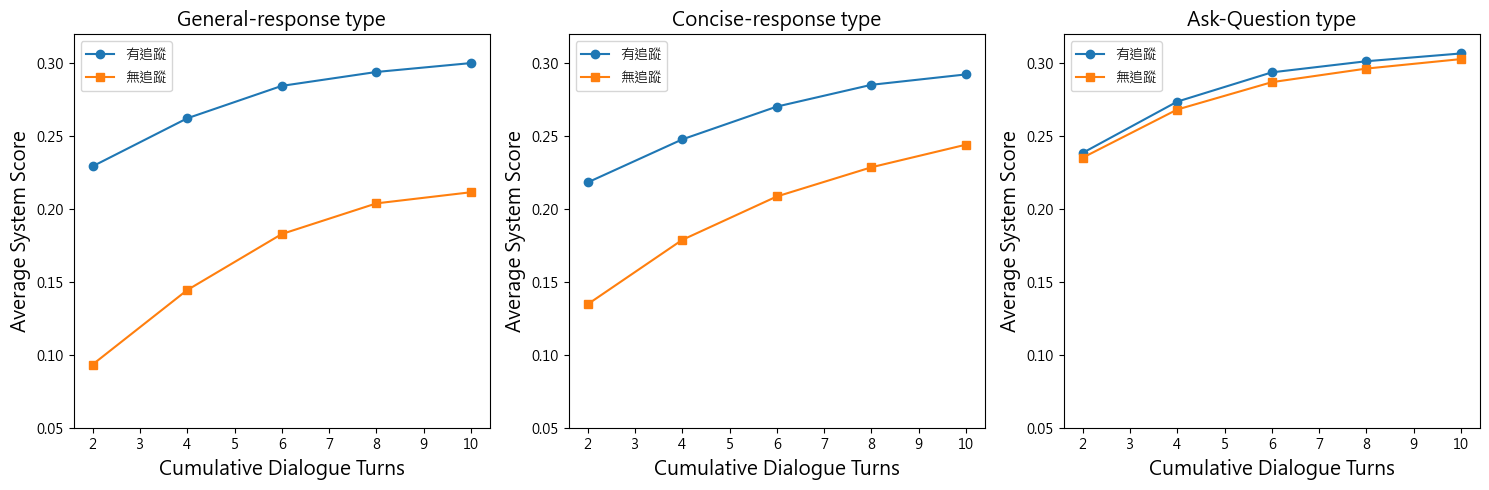

In [227]:
import matplotlib.pyplot as plt
mindmap = {}
with open('data/Freshman_Chinese/mindmap.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break
# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 建立圖表
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# 讀取學習曲線資料
learn_curve_data = []
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        learn_curve_data.append(json.loads(line))

# 依照不同風格和追蹤狀態分類資料
ask_style_data = {'traced': {}, 'untraced': {}}
concise_style_data = {'traced': {}, 'untraced': {}}
general_style_data = {'traced': {}, 'untraced': {}}

# 先計算每個輪次的平均分數
for record in learn_curve_data:
    round_num = record['round_num']
    kc_status = record['KC_status']
    style = record['student_style']
    tracing = record['tracing']
    topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, kc_status)
    
    trace_status = 'traced' if tracing else 'untraced'
    
    if style == 'ask_style':
        if round_num not in ask_style_data[trace_status]:
            ask_style_data[trace_status][round_num] = []
        ask_style_data[trace_status][round_num].append(overall_score)
    elif style == 'concise_style':
        if round_num not in concise_style_data[trace_status]:
            concise_style_data[trace_status][round_num] = []
        concise_style_data[trace_status][round_num].append(overall_score)
    elif style == 'general_style':
        if round_num not in general_style_data[trace_status]:
            general_style_data[trace_status][round_num] = []
        general_style_data[trace_status][round_num].append(overall_score)

# 計算平均值並轉換為繪圖用的格式
def get_plot_data(style_data, trace_status):
    return {
        'rounds': sorted(style_data[trace_status].keys()),
        'scores': [sum(style_data[trace_status][r])/len(style_data[trace_status][r]) 
                  for r in sorted(style_data[trace_status].keys())]
    }

# 繪製三種風格的折線圖，每種都包含追蹤和無追蹤兩條線
for ax, (style_name, style_data) in zip([ax1, ax2, ax3], 
                                      [('General-response type', general_style_data),
                                       ('Concise-response type', concise_style_data),
                                       ('Ask-Question type', ask_style_data)]):
    
    # 繪製有追蹤的線
    traced_data = get_plot_data(style_data, 'traced')
    ax.plot(traced_data['rounds'], traced_data['scores'], 
            marker='o', label='有追蹤')
    
    # 繪製無追蹤的線
    untraced_data = get_plot_data(style_data, 'untraced')
    ax.plot(untraced_data['rounds'], untraced_data['scores'], 
            marker='s', label='無追蹤')
    
    ax.set_title(style_name, fontsize=14)
    ax.set_xlabel('Cumulative Dialogue Turns', fontsize=14)
    ax.set_ylabel('Average System Score', fontsize=14)
    ax.set_ylim(0.05, 0.32)  # 設定y軸範圍
    ax.legend()

plt.tight_layout()

=== 學習曲線配對 t 檢定結果 ===

1. 正常回覆型學生:
   t統計量: 18.245
   p值: 0.000
   顯著性: 是
   有追蹤平均分: 0.274 ± 0.045 (n=145)
   無追蹤平均分: 0.167 ± 0.054 (n=145)

2. 簡潔回覆型學生:
   t統計量: 8.294
   p值: 0.000
   顯著性: 是
   有追蹤平均分: 0.263 ± 0.048 (n=145)
   無追蹤平均分: 0.199 ± 0.079 (n=145)

3. 提問型學生:
   t統計量: 0.966
   p值: 0.335
   顯著性: 否
   有追蹤平均分: 0.283 ± 0.042 (n=145)
   無追蹤平均分: 0.278 ± 0.044 (n=145)

=== 學習曲線 t 檢定結果摘要表 ===
 學生類型   t統計量    p值 顯著性        有追蹤平均分        無追蹤平均分  有追蹤樣本數  無追蹤樣本數
正常回覆型 18.245 0.000   是 0.274 ± 0.045 0.167 ± 0.054     145     145
簡潔回覆型  8.294 0.000   是 0.263 ± 0.048 0.199 ± 0.079     145     145
  提問型  0.966 0.335   否 0.283 ± 0.042 0.278 ± 0.044     145     145


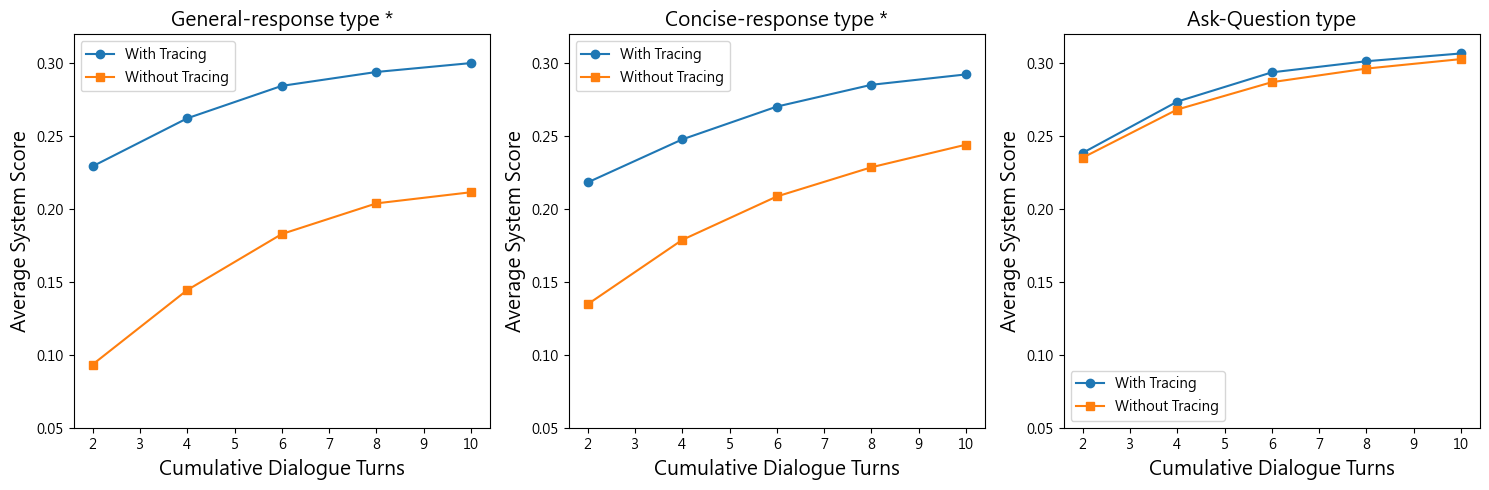

In [228]:
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

mindmap = {}
with open('data/Freshman_Chinese/mindmap.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break

# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 建立圖表
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# 讀取學習曲線資料
learn_curve_data = []
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        learn_curve_data.append(json.loads(line))

# 依照不同風格和追蹤狀態分類資料
ask_style_data = {'traced': {}, 'untraced': {}}
concise_style_data = {'traced': {}, 'untraced': {}}
general_style_data = {'traced': {}, 'untraced': {}}

# 先計算每個輪次的平均分數
for record in learn_curve_data:
    round_num = record['round_num']
    kc_status = record['KC_status']
    style = record['student_style']
    tracing = record['tracing']
    topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, kc_status)
    
    trace_status = 'traced' if tracing else 'untraced'
    
    if style == 'ask_style':
        if round_num not in ask_style_data[trace_status]:
            ask_style_data[trace_status][round_num] = []
        ask_style_data[trace_status][round_num].append(overall_score)
    elif style == 'concise_style':
        if round_num not in concise_style_data[trace_status]:
            concise_style_data[trace_status][round_num] = []
        concise_style_data[trace_status][round_num].append(overall_score)
    elif style == 'general_style':
        if round_num not in general_style_data[trace_status]:
            general_style_data[trace_status][round_num] = []
        general_style_data[trace_status][round_num].append(overall_score)

# 計算平均值並轉換為繪圖用的格式
def get_plot_data(style_data, trace_status):
    return {
        'rounds': sorted(style_data[trace_status].keys()),
        'scores': [sum(style_data[trace_status][r])/len(style_data[trace_status][r]) 
                  for r in sorted(style_data[trace_status].keys())]
    }

# 新增：進行整體配對 t 檢定
def perform_learning_curve_ttest(style_data, style_name):
    """對學習曲線資料進行有無追蹤的 t 檢定"""
    # 收集所有有追蹤和無追蹤的分數
    all_traced = []
    all_untraced = []
    
    for round_num in style_data['traced'].keys():
        all_traced.extend(style_data['traced'][round_num])
    
    for round_num in style_data['untraced'].keys():
        all_untraced.extend(style_data['untraced'][round_num])
    
    # 進行 t 檢定
    if all_traced and all_untraced:
        t_stat, p_value = stats.ttest_ind(all_traced, all_untraced)
        
        return {
            't_statistic': t_stat,
            'p_value': p_value,
            'significant': p_value < 0.05,
            'traced_mean': np.mean(all_traced),
            'untraced_mean': np.mean(all_untraced),
            'traced_std': np.std(all_traced),
            'untraced_std': np.std(all_untraced),
            'traced_count': len(all_traced),
            'untraced_count': len(all_untraced)
        }
    else:
        return {
            't_statistic': None,
            'p_value': None,
            'significant': None,
            'traced_mean': np.mean(all_traced) if all_traced else 0,
            'untraced_mean': np.mean(all_untraced) if all_untraced else 0,
            'traced_std': np.std(all_traced) if all_traced else 0,
            'untraced_std': np.std(all_untraced) if all_untraced else 0,
            'traced_count': len(all_traced),
            'untraced_count': len(all_untraced),
            'note': '缺少其中一組資料'
        }

# 對三種學習風格進行 t 檢定
general_ttest = perform_learning_curve_ttest(general_style_data, 'General-response type')
concise_ttest = perform_learning_curve_ttest(concise_style_data, 'Concise-response type')
ask_ttest = perform_learning_curve_ttest(ask_style_data, 'Ask-Question type')

# 顯示 t 檢定結果
print("=== 學習曲線配對 t 檢定結果 ===")
print("\n1. 正常回覆型學生:")
if general_ttest['t_statistic'] is not None:
    print(f"   t統計量: {general_ttest['t_statistic']:.3f}")
    print(f"   p值: {general_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if general_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {general_ttest['traced_mean']:.3f} ± {general_ttest['traced_std']:.3f} (n={general_ttest['traced_count']})")
    print(f"   無追蹤平均分: {general_ttest['untraced_mean']:.3f} ± {general_ttest['untraced_std']:.3f} (n={general_ttest['untraced_count']})")
else:
    print(f"   {general_ttest.get('note', '無法計算')}")

print("\n2. 簡潔回覆型學生:")
if concise_ttest['t_statistic'] is not None:
    print(f"   t統計量: {concise_ttest['t_statistic']:.3f}")
    print(f"   p值: {concise_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if concise_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {concise_ttest['traced_mean']:.3f} ± {concise_ttest['traced_std']:.3f} (n={concise_ttest['traced_count']})")
    print(f"   無追蹤平均分: {concise_ttest['untraced_mean']:.3f} ± {concise_ttest['untraced_std']:.3f} (n={concise_ttest['untraced_count']})")
else:
    print(f"   {concise_ttest.get('note', '無法計算')}")

print("\n3. 提問型學生:")
if ask_ttest['t_statistic'] is not None:
    print(f"   t統計量: {ask_ttest['t_statistic']:.3f}")
    print(f"   p值: {ask_ttest['p_value']:.3f}")
    print(f"   顯著性: {'是' if ask_ttest['significant'] else '否'}")
    print(f"   有追蹤平均分: {ask_ttest['traced_mean']:.3f} ± {ask_ttest['traced_std']:.3f} (n={ask_ttest['traced_count']})")
    print(f"   無追蹤平均分: {ask_ttest['untraced_mean']:.3f} ± {ask_ttest['untraced_std']:.3f} (n={ask_ttest['untraced_count']})")
else:
    print(f"   {ask_ttest.get('note', '無法計算')}")

# 繪製三種風格的折線圖，每種都包含追蹤和無追蹤兩條線
for ax, (style_name, style_data, ttest_result) in zip([ax1, ax2, ax3], 
                                      [('General-response type', general_style_data, general_ttest),
                                       ('Concise-response type', concise_style_data, concise_ttest),
                                       ('Ask-Question type', ask_style_data, ask_ttest)]):
    
    # 繪製有追蹤的線
    traced_data = get_plot_data(style_data, 'traced')
    ax.plot(traced_data['rounds'], traced_data['scores'], 
            marker='o', label='With Tracing')
    
    # 繪製無追蹤的線
    untraced_data = get_plot_data(style_data, 'untraced')
    ax.plot(untraced_data['rounds'], untraced_data['scores'], 
            marker='s', label='Without Tracing')
    
    # 新增：在圖表標題中顯示顯著性結果
    if ttest_result['significant']:
        title = f'{style_name} *'
    else:
        title = style_name
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Cumulative Dialogue Turns', fontsize=14)
    ax.set_ylabel('Average System Score', fontsize=14)
    ax.set_ylim(0.05, 0.32)  # 設定y軸範圍
    ax.legend()

plt.tight_layout()

# 新增：建立學習曲線 t 檢定結果摘要表
def create_learning_curve_ttest_summary():
    """建立學習曲線 t 檢定結果摘要表"""
    summary_data = []
    
    for ttest_result, student_type in [(general_ttest, '正常回覆型'), 
                                      (concise_ttest, '簡潔回覆型'), 
                                      (ask_ttest, '提問型')]:
        if ttest_result['t_statistic'] is not None:
            summary_data.append({
                '學生類型': student_type,
                't統計量': f"{ttest_result['t_statistic']:.3f}",
                'p值': f"{ttest_result['p_value']:.3f}",
                '顯著性': '是' if ttest_result['significant'] else '否',
                '有追蹤平均分': f"{ttest_result['traced_mean']:.3f} ± {ttest_result['traced_std']:.3f}",
                '無追蹤平均分': f"{ttest_result['untraced_mean']:.3f} ± {ttest_result['untraced_std']:.3f}",
                '有追蹤樣本數': ttest_result['traced_count'],
                '無追蹤樣本數': ttest_result['untraced_count']
            })
        else:
            summary_data.append({
                '學生類型': student_type,
                't統計量': 'N/A',
                'p值': 'N/A',
                '顯著性': 'N/A',
                '有追蹤平均分': f"{ttest_result['traced_mean']:.3f}",
                '無追蹤平均分': f"{ttest_result['untraced_mean']:.3f}",
                '有追蹤樣本數': ttest_result['traced_count'],
                '無追蹤樣本數': ttest_result['untraced_count'],
                '備註': ttest_result.get('note', '無法計算')
            })
    
    return pd.DataFrame(summary_data)

# 顯示學習曲線 t 檢定摘要表
learning_curve_ttest_summary = create_learning_curve_ttest_summary()
print("\n=== 學習曲線 t 檢定結果摘要表 ===")
print(learning_curve_ttest_summary.to_string(index=False))

### 散點圖繪製

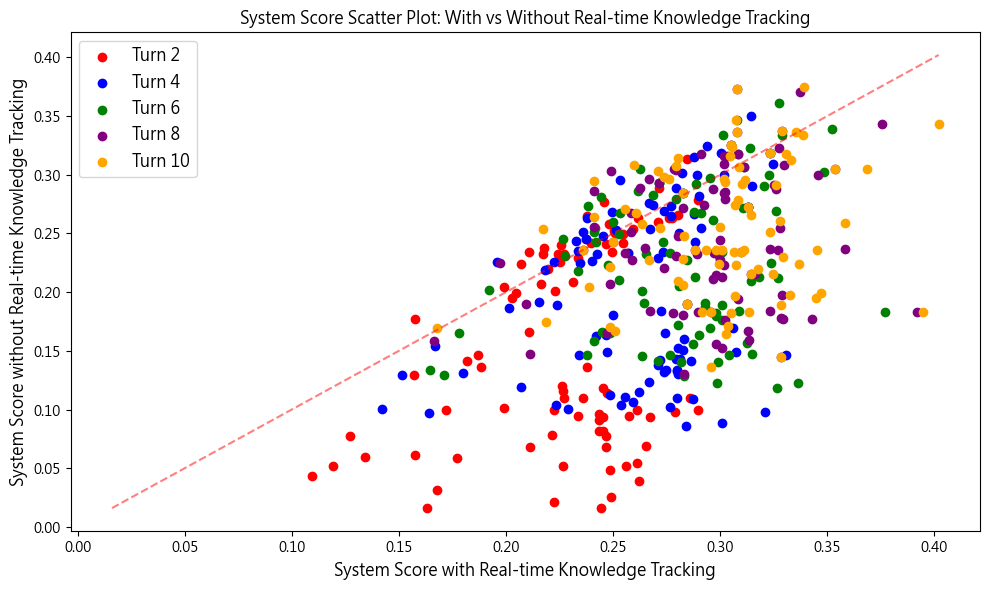

In [223]:
# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 建立散點圖資料
scatter_data = {
    'round_num': [],
    'traced_scores': [],
    'untraced_scores': []
}

# 讀取資料並配對有追蹤/無追蹤的成績
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    records = [json.loads(line) for line in f]

# 建立索引以快速查找配對資料
record_index = {}
for record in records:
    key = (record['user_id'], record['student_style'], record['round_num'])
    if key not in record_index:
        record_index[key] = {'traced': None, 'untraced': None}
    
    if record['tracing']:
        topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, record["KC_status"])
        record_index[key]['traced'] = overall_score
    else:
        topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, record["KC_status"])
        record_index[key]['untraced'] = overall_score

# 收集配對完整的資料點
for key, scores in record_index.items():
    if scores['traced'] is not None and scores['untraced'] is not None and key[2] in [2,4,6,8,10]:
        scatter_data['round_num'].append(key[2])
        scatter_data['traced_scores'].append(scores['traced'])
        scatter_data['untraced_scores'].append(scores['untraced'])

# 設定顏色對應
colors = {
    2: 'red',
    4: 'blue', 
    6: 'green',
    8: 'purple',
    10: 'orange'
}

# 繪製散點圖
plt.figure(figsize=(10, 6))

# 分別繪製每個輪次的點
for round_num in [2,4,6,8,10]:
    mask = [r == round_num for r in scatter_data['round_num']]
    plt.scatter(
        [x for x, m in zip(scatter_data['traced_scores'], mask) if m],
        [y for y, m in zip(scatter_data['untraced_scores'], mask) if m],
        c=colors[round_num],
        label=f'Turn {round_num}'
    )

plt.xlabel('System Score with Real-time Knowledge Tracking', fontsize=12)
plt.ylabel('System Score without Real-time Knowledge Tracking', fontsize=12)
plt.title('System Score Scatter Plot: With vs Without Real-time Knowledge Tracking', fontsize=12)
plt.legend(fontsize=12)

# 添加對角線
min_score = min(min(scatter_data['traced_scores']), min(scatter_data['untraced_scores']))
max_score = max(max(scatter_data['traced_scores']), max(scatter_data['untraced_scores']))
plt.plot([min_score, max_score], [min_score, max_score], 'r--', alpha=0.5)

plt.tight_layout()
plt.show()

=== 右下角區域分析 ===
總點數: 435
右下角區域點數: 323
右下角區域百分比: 74.3%

=== 各輪次右下角區域分析 ===
輪次 2: 66/87 點 (75.9%)
輪次 4: 65/87 點 (74.7%)
輪次 6: 62/87 點 (71.3%)
輪次 8: 66/87 點 (75.9%)
輪次 10: 64/87 點 (73.6%)


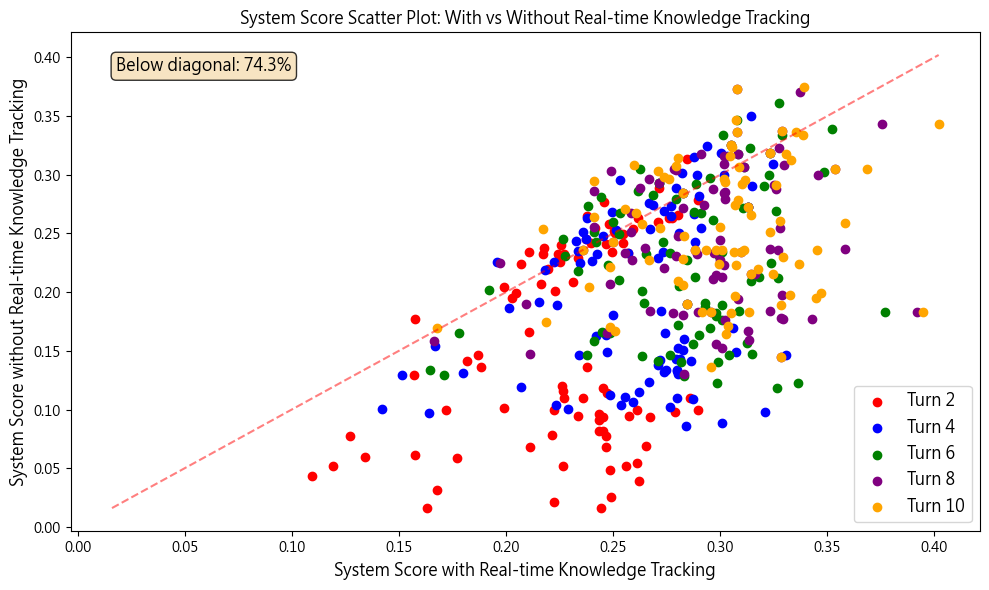


=== 詳細區域分析 ===
右下角區域 (有追蹤 > 無追蹤): 323 點 (74.3%)
左上角區域 (有追蹤 < 無追蹤): 112 點 (25.7%)
對角線上 (有追蹤 = 無追蹤): 0 點 (0.0%)


In [229]:
# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 建立散點圖資料
scatter_data = {
    'round_num': [],
    'traced_scores': [],
    'untraced_scores': []
}

# 讀取資料並配對有追蹤/無追蹤的成績
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    records = [json.loads(line) for line in f]

# 建立索引以快速查找配對資料
record_index = {}
for record in records:
    key = (record['user_id'], record['student_style'], record['round_num'])
    if key not in record_index:
        record_index[key] = {'traced': None, 'untraced': None}
    
    if record['tracing']:
        topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, record["KC_status"])
        record_index[key]['traced'] = overall_score
    else:
        topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, record["KC_status"])
        record_index[key]['untraced'] = overall_score

# 收集配對完整的資料點
for key, scores in record_index.items():
    if scores['traced'] is not None and scores['untraced'] is not None and key[2] in [2,4,6,8,10]:
        scatter_data['round_num'].append(key[2])
        scatter_data['traced_scores'].append(scores['traced'])
        scatter_data['untraced_scores'].append(scores['untraced'])

# 新增：計算右下角區域的百分比
def calculate_below_diagonal_percentage(traced_scores, untraced_scores):
    """計算在對角線下方（右下角區域）的點數百分比"""
    total_points = len(traced_scores)
    below_diagonal_count = 0
    
    for traced, untraced in zip(traced_scores, untraced_scores):
        if traced > untraced:  # 在對角線下方
            below_diagonal_count += 1
    
    percentage = (below_diagonal_count / total_points) * 100
    return below_diagonal_count, total_points, percentage

# 計算整體的右下角區域百分比
below_diagonal_count, total_points, overall_percentage = calculate_below_diagonal_percentage(
    scatter_data['traced_scores'], scatter_data['untraced_scores']
)

print(f"=== 右下角區域分析 ===")
print(f"總點數: {total_points}")
print(f"右下角區域點數: {below_diagonal_count}")
print(f"右下角區域百分比: {overall_percentage:.1f}%")

# 按輪次分別計算
print(f"\n=== 各輪次右下角區域分析 ===")
for round_num in [2, 4, 6, 8, 10]:
    mask = [r == round_num for r in scatter_data['round_num']]
    round_traced = [x for x, m in zip(scatter_data['traced_scores'], mask) if m]
    round_untraced = [y for y, m in zip(scatter_data['untraced_scores'], mask) if m]
    
    if round_traced:  # 確保該輪次有資料
        count, total, percentage = calculate_below_diagonal_percentage(round_traced, round_untraced)
        print(f"輪次 {round_num}: {count}/{total} 點 ({percentage:.1f}%)")

# 設定顏色對應
colors = {
    2: 'red',
    4: 'blue', 
    6: 'green',
    8: 'purple',
    10: 'orange'
}

# 繪製散點圖
plt.figure(figsize=(10, 6))

# 分別繪製每個輪次的點
for round_num in [2,4,6,8,10]:
    mask = [r == round_num for r in scatter_data['round_num']]
    plt.scatter(
        [x for x, m in zip(scatter_data['traced_scores'], mask) if m],
        [y for y, m in zip(scatter_data['untraced_scores'], mask) if m],
        c=colors[round_num],
        label=f'Turn {round_num}'
    )

plt.xlabel('System Score with Real-time Knowledge Tracking', fontsize=12)
plt.ylabel('System Score without Real-time Knowledge Tracking', fontsize=12)
plt.title('System Score Scatter Plot: With vs Without Real-time Knowledge Tracking', fontsize=12)
plt.legend(fontsize=12)

# 添加對角線
min_score = min(min(scatter_data['traced_scores']), min(scatter_data['untraced_scores']))
max_score = max(max(scatter_data['traced_scores']), max(scatter_data['untraced_scores']))
plt.plot([min_score, max_score], [min_score, max_score], 'r--', alpha=0.5, label='Diagonal line')

# 新增：在圖表上標示百分比資訊
plt.text(0.05, 0.95, f'Below diagonal: {overall_percentage:.1f}%', 
         transform=plt.gca().transAxes, fontsize=12, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

# 新增：詳細的區域分析
print(f"\n=== 詳細區域分析 ===")
above_diagonal_count = 0
on_diagonal_count = 0

for traced, untraced in zip(scatter_data['traced_scores'], scatter_data['untraced_scores']):
    if traced > untraced:
        above_diagonal_count += 1  # 實際上是右下角區域
    elif traced < untraced:
        pass  # 左上角區域
    else:
        on_diagonal_count += 1  # 在對角線上

print(f"右下角區域 (有追蹤 > 無追蹤): {above_diagonal_count} 點 ({above_diagonal_count/total_points*100:.1f}%)")
print(f"左上角區域 (有追蹤 < 無追蹤): {total_points - above_diagonal_count - on_diagonal_count} 點 ({(total_points - above_diagonal_count - on_diagonal_count)/total_points*100:.1f}%)")
print(f"對角線上 (有追蹤 = 無追蹤): {on_diagonal_count} 點 ({on_diagonal_count/total_points*100:.1f}%)")

### 實驗 5: 在即時知識追蹤中應用教學策略控制對話走向

In [203]:
import configparser
import json
from openai import OpenAI
import time
import main
import os
from tqdm import tqdm

config = configparser.ConfigParser()
config.read('./config.ini')
client_openai = OpenAI(
    organization = config['openai']['organization'],
    api_key = config['openai']['api_key']
)

#mindmap
mindmap = {}
with open('data/Freshman_Chinese/mindmap.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break

def get_thread_messages(thread_id):
    """獲取指定 thread 的所有訊息"""
    messages = client_openai.beta.threads.messages.list(thread_id=thread_id)
    thread_log = []
    
    for msg in reversed(messages.data):  # 反轉以獲得時間順序
        thread_log.append({
            "role": msg.role,
            "content": msg.content[0].text.value
        })
    
    return thread_log

def run_knowledge_tracking(dialogue, need_report = False, mindmap = None):
    """
    進行知識追蹤
    """
    course_id = "Freshman_Chinese"
    # 構建知識追蹤的輸入格式
    user_status = main.get_or_create_user("simulated_user", course_id, "simulated_user")
    
    anno_nodes, KC_information = main.annotate_knowledge_points(dialogue, course_id)
    anno_mastery = None

    if len(anno_nodes) > 5:
        all_mastery_results = []
        # 每5個節點分組處理
        for i in range(0, len(anno_nodes), 5):
            nodes_subset = anno_nodes[i:i+5]
            anno_mastery = main.annotate_mastery(
                "simulated_user",
                nodes_subset,
                KC_information,
                dialogue,
                time="2025/07/17",
                course_id=course_id,
                user_name="simulated_user",
                conversation_id="simulated_conversation",
                update_user_status=True,
                store_trace_result=True,
                real_time=True
            )
            if anno_mastery:
                all_mastery_results.extend(anno_mastery)
        anno_mastery = all_mastery_results
    else:
        # 如果節點數小於等於5，直接處理全部
        anno_mastery = main.annotate_mastery(
            "simulated_user",
            anno_nodes,
            KC_information,
            dialogue,
            time="2025/07/17",
            course_id=course_id,
            user_name="simulated_user",
            conversation_id="simulated_conversation",
            update_user_status=True,
            store_trace_result=True,
            real_time=True
        )

    new_history_items = []
    report = "[當前追蹤報告]"

    if mindmap:
        # 取得主要知識點
        main_kc_names = [kc["KC_name"] for kc in mindmap["knowledge_points"]]
        
        # 取得子節點的知識點
        children_kc_names = []
        for child in mindmap["children"]:
            if "knowledge_points" in child:
                children_kc_names.extend([kc["KC_name"] for kc in child["knowledge_points"]])
                
        # 取聯集去除重複
        all_kc_names = list(set(main_kc_names + children_kc_names))

    if anno_mastery:
        if need_report:
            # 深化已知教學策略
            has_score_change = False
            score_changes = []
            for kc in anno_mastery:
                existing_kc = next((k for k in user_status["user_KC_status"] if k["KC_name"] == kc["KC_name"]), None)
                if existing_kc and existing_kc['mastery_score'] != kc['mastery_score']:
                    has_score_change = True
                    score_changes.append({
                        'kc_name': kc['KC_name'],
                        'old_score': existing_kc['mastery_score'],
                        'new_score': kc['mastery_score']
                    })
                    # 比對 mastery_history 並找出新增的元素
                    new_history_items = [
                        item for item in kc["mastery_history"] 
                        if item not in existing_kc["mastery_history"]
                    ]
            
            if has_score_change:  
                report += "\n目前學生在以下知識點的分數有所提升，建議繼續朝向這些知識討論、深化學生已知。"
                for change in score_changes:
                    report += f"\n- {change['kc_name']}的分數 {change['old_score']} -> {change['new_score']}"
                if new_history_items != []:
                    report += "\n分數判斷事件:"
                    for item in new_history_items:
                        report += f"\n - {item['event']}"
            else:
                report += "\n目前的討論內容沒有分數變化，以下的內容是學生較為熟悉的知識，建議朝向這些知識討論、深化學生已知。"
                # 取得分數最高的5個知識點
                sorted_kcs = sorted(user_status["user_KC_status"], 
                                 key=lambda x: x['mastery_score'], 
                                 reverse=True)[:5]
                for kc in sorted_kcs:
                    report += f"\n- {kc['KC_name']}: {kc['mastery_score']}"

            # 擴展新知教學策略
            # report += "\n目前的教學策略為擴展新知，請參考以下尚未接觸的知識點:"
            
            # # 從 mindmap 取得所有知識點
            # mindmap_kcs = all_kc_names if mindmap else []
            
            # # 從 user_status 取得已知知識點
            # known_kcs = [kc["KC_name"] for kc in user_status["user_KC_status"]]
            
            # # 找出未知的知識點
            # unknown_kcs = [kc for kc in mindmap_kcs if kc not in known_kcs]
            
            # if unknown_kcs:
            #     for kc in unknown_kcs:
            #         report += f"\n- {kc}"
            # else:
            #     report += "\n目前重要的知識點皆已接觸，以下是掌握度較低的知識點及分數:"
            #     # 取得分數最低的5個知識點
            #     sorted_kcs = sorted(user_status["user_KC_status"], 
            #                     key=lambda x: x['mastery_score'])[:5]
            #     for kc in sorted_kcs:
            #         report += f"\n- {kc['KC_name']}: {kc['mastery_score']}"
            
            return anno_mastery, report
        else:
            return anno_mastery
    else:
        if need_report:
            return [], ""
        else:
            return []

def run_assistant_and_wait(assistant_id, thread_id):
    """執行助理並等待完成，返回回應內容"""
    # 建立並執行對話
    run = client_openai.beta.threads.runs.create(
        thread_id=thread_id,
        assistant_id=assistant_id
    )
    
    # 輪詢執行結果
    while True:
        run_status = client_openai.beta.threads.runs.retrieve(
            thread_id=thread_id, 
            run_id=run.id
        )
        if run_status.status == "completed":
            break
        elif run_status.status == "failed":
            print(f"執行失敗: {run_status.last_error}")
            return None
        else:
            time.sleep(1)
    
    # 取得最新回應
    messages = client_openai.beta.threads.messages.list(thread_id=thread_id)
    return messages.data[0].content[0].text.value

def auto_conversation(max_rounds=6, initial_message="你好", tracing = False, mindmap_file_name = None):
    """最簡潔的分離 thread 實現"""
    
    # 每次對話都創建新的 threads
    ta_thread = client_openai.beta.threads.create()
    student_thread = client_openai.beta.threads.create()
    
    # 存儲純淨的對話記錄（不包含知識追蹤結果）
    clean_conversation_log = []

    # 初始化：給 TA 發送初始訊息
    client_openai.beta.threads.messages.create(
        thread_id=ta_thread.id,
        role="user",
        content=initial_message
    )

    mindmap_path = f"data/Freshman_Chinese/mindmap.jsonl"
    mindmap = None

    # 讀取 mindmap 檔案
    with open(mindmap_path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['file_name'] == mindmap_file_name:
                mindmap = data['mindmap']
                break

    # 用於儲存每次計算的主題分數
    topic_scores_history = []
    
    for round_num in range(max_rounds):
        # print(f"=== 第 {round_num + 1} 輪 ===")
        
        # TA 說話
        ta_response = run_assistant_and_wait(TA_assistant.id, ta_thread.id)
        if ta_response is None:
            break
        # print(f"assistant: {ta_response}")
        
        # 記錄到純淨對話日誌
        clean_conversation_log.append({
            "role": "assistant",
            "content": ta_response
        })

        # 轉發給 Student
        client_openai.beta.threads.messages.create(
            thread_id=student_thread.id,
            role="user",
            content=ta_response
        )
        
        # Student 回應
        student_response = run_assistant_and_wait(select_student.id, student_thread.id)
        if student_response is None:
            break
        # print(f"user: {student_response}")
        
        clean_conversation_log.append({
            "role": "user",
            "content": student_response
        })
        # print("-" * 20)

        # 轉發給 TA（為下一輪準備）
        if round_num < max_rounds:
            client_openai.beta.threads.messages.create(
                thread_id=ta_thread.id,
                role="user",
                content=student_response
            )
            
            # if (round_num+1) % 2 == 0:
            tracing_result, report = run_knowledge_tracking(clean_conversation_log, need_report=True, mindmap=mindmap)
            #取得 simulated_user 的 user_status
            file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    user_data = json.loads(line)
                    if user_data['user_id'] == 'simulated_user':
                        kc_status = user_data['user_KC_status']
                        break
            topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, kc_status)
            topic_scores_history.append(topic_scores)
            if tracing:
                if report != "":
                    client_openai.beta.threads.messages.create(
                        thread_id=ta_thread.id,
                        role="user",
                        content=report
                    )
        # print("-" * 20)

    # 繪製雷達圖顯示分數變化
    if len(topic_scores_history) > 0:
        # 獲取所有主題名稱
        topics = list(topic_scores_history[0].keys())
        angles = np.linspace(0, 2*np.pi, len(topics), endpoint=False)
        
        # 建立圖表
        plt.figure(figsize=(10, 8))
        ax = plt.subplot(111, projection='polar')

        # 在繪製雷達圖之前，先計算所有分數的範圍
        all_scores = []
        for scores in topic_scores_history:
            all_scores.extend(list(scores.values()))

        # 動態設置 ylim
        min_score = min(all_scores) if all_scores else 0
        max_score = max(all_scores) if all_scores else 1
        margin = (max_score - min_score) * 0.1  # 添加 10% 的邊距
        ax.set_ylim(max(0, min_score - margin), min(1, max_score + margin))

        # 繪製雷達圖網格
        ax.set_xticks(angles)
        ax.set_xticklabels(topics)

        # 記錄前一輪的分數
        prev_scores = {topic: 0 for topic in topics}

        # 為每一輪對話繪製分數變化
        for i, scores in enumerate(topic_scores_history):
            # 繪製當前分數的點
            values = [scores[topic] for topic in topics]
            values.append(values[0])  # 閉合多邊形
            angles_plot = np.concatenate([angles, [angles[0]]])  # 閉合多邊形
            
            ax.plot(angles_plot, values, 'o-', label=f'第{(i+1)*2}輪', alpha=0.6)
            
            # 如果不是第一輪，找出變化最大的主題並繪製箭頭
            if i > 0:
                # 計算每個主題的分數變化
                changes = {topic: abs(scores[topic] - prev_scores[topic]) for topic in topics}
                # 找出變化最大的主題
                max_change_topic = max(changes.items(), key=lambda x: x[1])[0]
                max_change_idx = topics.index(max_change_topic)
                
                # 只為變化最大的主題繪製箭頭
                if changes[max_change_topic] > 0:  # 確保有實際變化
                    ax.annotate("",
                              xy=(angles[max_change_idx], scores[max_change_topic]), 
                              xytext=(angles[max_change_idx], prev_scores[max_change_topic]),
                              arrowprops=dict(arrowstyle="->", 
                                            color='red',
                                            lw=2),
                              annotation_clip=False)
            
            # 更新前一輪分數
            prev_scores = scores.copy()

        plt.title('主題分數變化雷達圖')
        plt.legend(loc='upper right')
        plt.show()

    ta_thread_log = get_thread_messages(ta_thread.id)
    student_thread_log = get_thread_messages(student_thread.id)

    # 刪除虛擬使用者在 user_status.jsonl 的資料
    try:
        file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
        if os.path.exists(file_path):
            # 讀取現有的使用者資料
            with open(file_path, 'r', encoding='utf-8') as f:
                users = [json.loads(line) for line in f]
            
            # 過濾掉虛擬使用者的資料
            filtered_users = [user for user in users 
                            if user['user_id'] not in ['simulated_user']]
            
            # 重新寫入過濾後的資料
            with open(file_path, 'w', encoding='utf-8') as f:
                for user in filtered_users:
                    f.write(json.dumps(user, ensure_ascii=False) + '\n')
            
            print("已刪除虛擬使用者資料")
    except Exception as e:
        print(f"刪除虛擬使用者資料時發生錯誤: {e}")
    return clean_conversation_log, ta_thread_log, student_thread_log

已寫入虛擬使用者資料


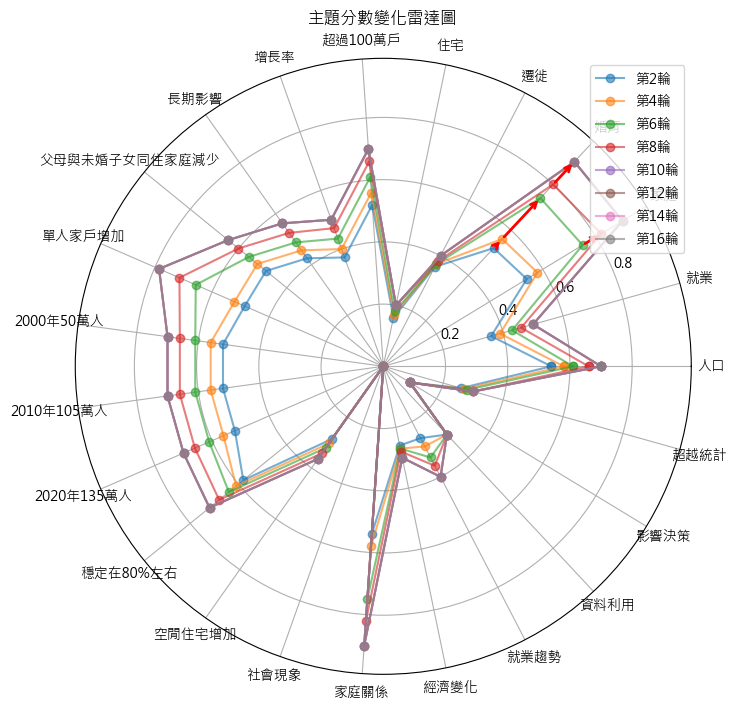

已刪除虛擬使用者資料


In [ ]:
concise_style = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你曾接觸過教材，但回應風格簡潔、話不多。

你的表現風格是：會回答助教的問題，但多半用簡短的一句話、甚至幾個單詞應答。你很少主動延伸話題，也不常提問，讓助教主導整體節奏。

請注意：請保持語言簡潔自然，不要展現過多的知識或熱情，模擬一位回覆偏保守的學生。
"""

user_id = 113403034
round_num = 8

# 從 user_status.jsonl 讀取使用者的 KC 狀態
user_KC_status = {}
try:
    with open('data/Freshman_Chinese/user_status.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['user_id'] == user_id:
                user_KC_status = data['user_KC_status']
                break
except Exception as e:
    print(f"讀取使用者狀態時發生錯誤: {e}")

# 載入虛擬學習檔案
try:
    file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
    
    # 建立虛擬使用者資料
    simulated_user = {
        "user_id": "simulated_user",
        "user_name": "simulated_user",
        "user_KC_status": KC_status
    }
    
    # 寫入虛擬使用者資料
    with open(file_path, 'a', encoding='utf-8') as f:
        f.write(json.dumps(simulated_user, ensure_ascii=False) + '\n')
    
    print("已寫入虛擬使用者資料")
except Exception as e:
    print(f"寫入虛擬使用者資料時發生錯誤: {e}")

KC_status_str = json.dumps(user_KC_status, ensure_ascii=False, indent=2)
current_prompt = student_prompt.format(student_style=concise_style, topic_name="2020年人口及住宅普查", KC_status=KC_status_str)
select_student = client_openai.beta.assistants.retrieve("asst_1234")
# 更新模擬學生的系統提示
select_student = client_openai.beta.assistants.update(
    assistant_id="asst_1234",
    instructions=current_prompt
)
# 簡報協同製作代理人
TA_assistant = client_openai.beta.assistants.retrieve("asst_1234")
clean_log, ta_log, student_log = auto_conversation(max_rounds=round_num, tracing=True, mindmap_file_name="2020年人口及住宅普查.pdf")


已寫入虛擬使用者資料


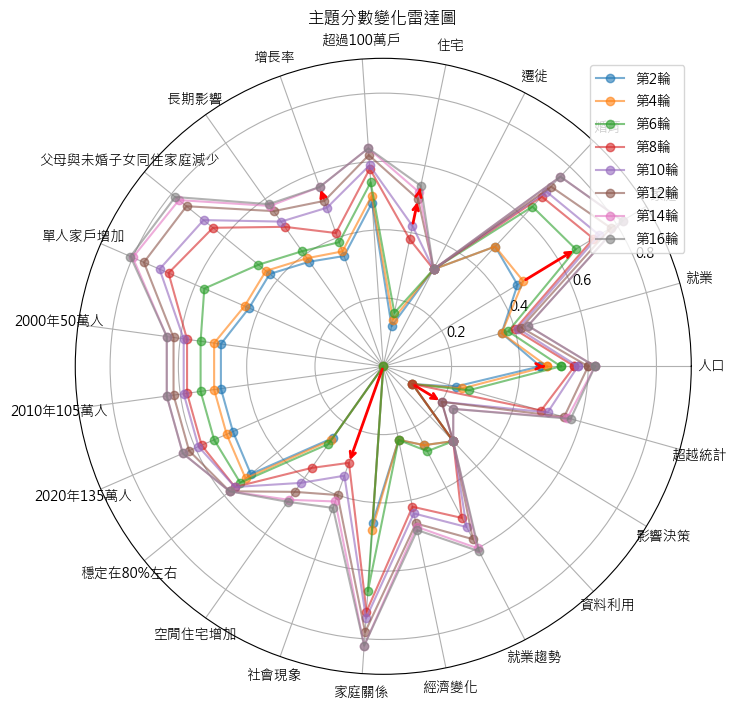

已刪除虛擬使用者資料


In [ ]:
concise_style = """
你是一名大學生，正在與助教討論「2020年人口與住宅普查」所反映出的臺灣社會趨勢。你曾接觸過教材，但回應風格簡潔、話不多。

你的表現風格是：會回答助教的問題，但多半用簡短的一句話、甚至幾個單詞應答。你很少主動延伸話題，也不常提問，讓助教主導整體節奏。

請注意：請保持語言簡潔自然，不要展現過多的知識或熱情，模擬一位回覆偏保守的學生。
"""

user_id = 113403034
round_num = 8

# 從 user_status.jsonl 讀取使用者的 KC 狀態
user_KC_status = {}
try:
    with open('data/Freshman_Chinese/user_status.jsonl', 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            if data['user_id'] == user_id:
                user_KC_status = data['user_KC_status']
                break
except Exception as e:
    print(f"讀取使用者狀態時發生錯誤: {e}")

# 載入虛擬學習檔案
try:
    file_path = os.path.join("data", "Freshman_Chinese", "user_status.jsonl")
    
    # 建立虛擬使用者資料
    simulated_user = {
        "user_id": "simulated_user",
        "user_name": "simulated_user",
        "user_KC_status": KC_status
    }
    
    # 寫入虛擬使用者資料
    with open(file_path, 'a', encoding='utf-8') as f:
        f.write(json.dumps(simulated_user, ensure_ascii=False) + '\n')
    
    print("已寫入虛擬使用者資料")
except Exception as e:
    print(f"寫入虛擬使用者資料時發生錯誤: {e}")

KC_status_str = json.dumps(user_KC_status, ensure_ascii=False, indent=2)
current_prompt = student_prompt.format(student_style=concise_style, topic_name="2020年人口及住宅普查", KC_status=KC_status_str)
select_student = client_openai.beta.assistants.retrieve("asst_1234")
# 更新模擬學生的系統提示
select_student = client_openai.beta.assistants.update(
    assistant_id="asst_1234",
    instructions=current_prompt
)
# 簡報協同製作代理人
TA_assistant = client_openai.beta.assistants.retrieve("asst_1234")
clean_log, ta_log, student_log = auto_conversation(max_rounds=round_num, tracing=True, mindmap_file_name="2020年人口及住宅普查.pdf")


In [201]:
# 印出 TA 的對話紀錄
print("TA 對話紀錄:")
for idx, log in enumerate(ta_log, 1):
    print(f"{log['role']}: {log['content']}")
    print("-" * 50)


TA 對話紀錄:
user: 我們可以從未婚人口、少子化和高齡化三個方面切入。這些趨勢直接影響家庭結構和社會發展。未婚人口的增加和婚姻觀念的改變可以是例子，還有少子化對生育率的影響。
--------------------------------------------------
user: [當前追蹤報告]
目前學生在以下知識點的分數有所提升，建議繼續朝向這些知識討論、深化學生已知。
- 2020年人口及住宅普查的分數 0.8 -> 0.85
分數判斷事件:
 - 用戶提到家庭結構受到未婚人口和少子化影響，顯示出對家庭結構變化的理解有所加深。
- 未婚人口的分數 0.7 -> 0.75
分數判斷事件:
 - 用戶提到家庭結構受到未婚人口和少子化影響，顯示出對家庭結構變化的理解有所加深。
- 少子化的分數 0.6 -> 0.7
分數判斷事件:
 - 用戶提到家庭結構受到未婚人口和少子化影響，顯示出對家庭結構變化的理解有所加深。
- 家庭結構的分數 0.8 -> 0.85
分數判斷事件:
 - 用戶提到家庭結構受到未婚人口和少子化影響，顯示出對家庭結構變化的理解有所加深。
--------------------------------------------------
assistant: 非常好！未婚人口、少子化和高齡化確實是影響當前家庭結構和社會發展的重要趨勢。

接下來，我們可以針對每個趨勢進一步討論它們的意義及具體例子：

1. **未婚人口**：你提到未婚人口的增加和婚姻觀念的改變，這可以引出一些具體的數據或案例，比如未婚比例的增長趨勢、年齡層的變化等。

2. **少子化**：這方面可以討論生育率下降的原因，例如人們的經濟考量和職場競爭，加上相對的育兒成本等影響。

3. **高齡化**：可以探討老年人口比例上升對家庭及社會的挑戰，比如照護需求的增加。

對於這些趨勢，你覺得我們應該從哪些具體的數據或者研究資料來支持這些例子呢？如果有特定的數據來源或者調查結果，分享一下也很好！
--------------------------------------------------
user: 對於未婚人口，可以使用2020年普查中的比例數據，顯示年輕人未婚率的增長。少子化方面，可以引用生育率下降的具體數字，說明家庭經濟壓力和駐留時間延長的影響。高齡化

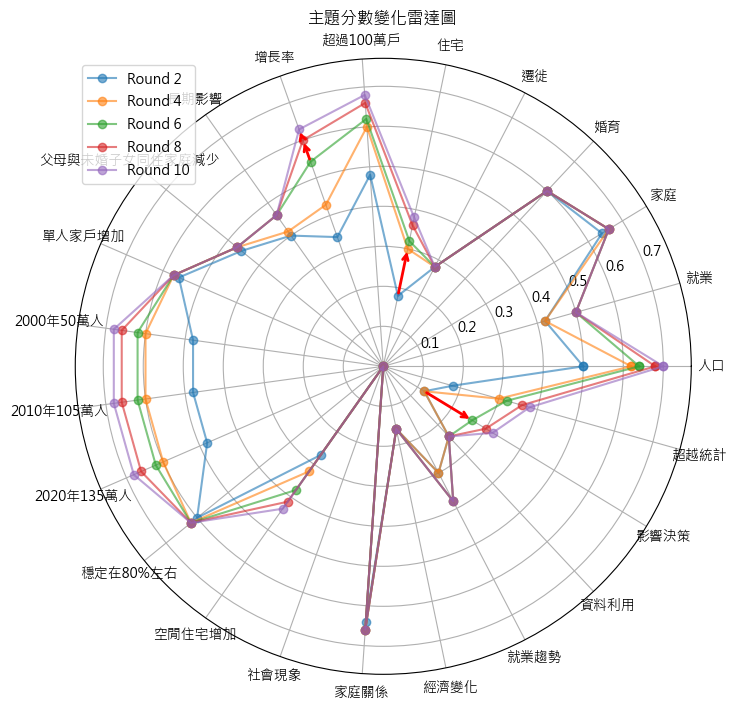

In [196]:
# 雷達圖建置測試
import matplotlib.pyplot as plt
import numpy as np
mindmap = {}
with open('data/Freshman_Chinese/mindmap.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        data = json.loads(line)
        if data['file_name'] == "2020年人口及住宅普查.pdf":
            mindmap = data['mindmap']
            break
# 設定中文字型
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False
# 讀取學習曲線資料
learn_curve_data = []
with open('data/Freshman_Chinese/learn_curve.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        learn_curve_data.append(json.loads(line))
# 篩選指定學生的學習曲線資料
student_data = [d for d in learn_curve_data 
               if d['user_id'] == 113403034 and  # 113403034
               # 111303057, 111303064, 111802005, 113403005,
               # 113403011, 113403017, 113403034, 113403504
               d['student_style'] == 'concise_style' and # general_style, ask_style, concise_style
               d['tracing'] == True]

# 依照 round_num 排序
student_data.sort(key=lambda x: x['round_num'])

# 建立圖表
plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='polar')

# 取得所有主題
topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, student_data[0]['KC_status'])
topics = list(topic_scores.keys())
angles = np.linspace(0, 2*np.pi, len(topics), endpoint=False)

# 在繪製雷達圖之前，先計算所有分數的範圍
all_scores = []
for data in student_data:
    topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, data['KC_status'])
    all_scores.extend(list(topic_scores.values()))

# 動態設置 ylim
min_score = min(all_scores) if all_scores else 0
max_score = max(all_scores) if all_scores else 1
margin = (max_score - min_score) * 0.1  # 添加 10% 的邊距

ax.set_ylim(max(0, min_score - margin), min(1, max_score + margin))

# 繪製雷達圖網格
ax.set_xticks(angles)
ax.set_xticklabels(topics)

# 記錄前一輪的分數
prev_scores = {topic: 0 for topic in topics}

# 為每一輪對話繪製分數變化
for i, data in enumerate(student_data):
    # 計算當前輪的主題分數
    topic_scores, overall_score = calculate_topic_scores_learn_curve(mindmap, data['KC_status'])
    
    # 繪製當前分數的點
    values = [topic_scores[topic] for topic in topics]
    values.append(values[0])  # 閉合多邊形
    angles_plot = np.concatenate([angles, [angles[0]]])  # 閉合多邊形
    
    ax.plot(angles_plot, values, 'o-', label=f'Round {data["round_num"]}', alpha=0.6)
    
    # 如果不是第一輪，找出變化最大的主題
    if i > 0:
        # 計算每個主題的變化量
        changes = {topic: abs(topic_scores[topic] - prev_scores[topic]) for topic in topics}
        # 找出變化最大的主題
        max_change_topic = max(changes.items(), key=lambda x: x[1])[0]
        max_change_idx = topics.index(max_change_topic)
        
        # 只為變化最大的主題繪製箭頭
        if changes[max_change_topic] > 0:  # 只有當變化量大於0時才繪製
            ax.annotate("",
                      xy=(angles[max_change_idx], topic_scores[max_change_topic]), 
                      xytext=(angles[max_change_idx], prev_scores[max_change_topic]),
                      arrowprops=dict(arrowstyle="->", 
                                    color='red',
                                    lw=2),
                      annotation_clip=False)
    
    # 更新前一輪分數
    prev_scores = topic_scores.copy()

plt.title('主題分數變化雷達圖')
plt.legend(loc='upper left')
plt.show()
